# Supervised Learning - Foundations Project: ReCell

## Problem Statement

### Business Context

Buying and selling used phones and tablets used to be something that happened on a handful of online marketplace sites. But the used and refurbished device market has grown considerably over the past decade, and a new IDC (International Data Corporation) forecast predicts that the used phone market would be worth \\$52.7bn by 2023 with a compound annual growth rate (CAGR) of 13.6% from 2018 to 2023. This growth can be attributed to an uptick in demand for used phones and tablets that offer considerable savings compared with new models.

Refurbished and used devices continue to provide cost-effective alternatives to both consumers and businesses that are looking to save money when purchasing one. There are plenty of other benefits associated with the used device market. Used and refurbished devices can be sold with warranties and can also be insured with proof of purchase. Third-party vendors/platforms, such as Verizon, Amazon, etc., provide attractive offers to customers for refurbished devices. Maximizing the longevity of devices through second-hand trade also reduces their environmental impact and helps in recycling and reducing waste. The impact of the COVID-19 outbreak may further boost this segment as consumers cut back on discretionary spending and buy phones and tablets only for immediate needs.


### Objective

The rising potential of this comparatively under-the-radar market fuels the need for an ML-based solution to develop a dynamic pricing strategy for used and refurbished devices. ReCell, a startup aiming to tap the potential in this market, has hired you as a data scientist. They want you to analyze the data provided and build a linear regression model to predict the price of a used phone/tablet and identify factors that significantly influence it.


### Data Description

The data contains the different attributes of used/refurbished phones and tablets. The data was collected in the year 2021. The detailed data dictionary is given below.


- brand_name: Name of manufacturing brand
- os: OS on which the device runs
- screen_size: Size of the screen in cm
- 4g: Whether 4G is available or not
- 5g: Whether 5G is available or not
- main_camera_mp: Resolution of the rear camera in megapixels
- selfie_camera_mp: Resolution of the front camera in megapixels
- int_memory: Amount of internal memory (ROM) in GB
- ram: Amount of RAM in GB
- battery: Energy capacity of the device battery in mAh
- weight: Weight of the device in grams
- release_year: Year when the device model was released
- days_used: Number of days the used/refurbished device has been used
- normalized_new_price: Normalized price of a new device of the same model in euros
- normalized_used_price: Normalized price of the used/refurbished device in euros

## Importing necessary libraries

In [ ]:
# imports the necessary libraries for data manipulation
import numpy as np
import pandas as pd

# imports the necessary libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# imports the necessary library for statistical analysis
from scipy import stats

# imports the ttest_ind function from the scipy library.
from scipy.stats import ttest_ind

# imports the proportions_ztest function from the statsmodels library.
from statsmodels.stats.proportion import proportions_ztest

# imports the chi2_contingency function from the scipy library.
from scipy.stats import chi2_contingency

# imports the f_oneway function from the scipy library.
from scipy.stats import f_oneway

# command to tell Python to actually display the graphs
%matplotlib inline

# imports plotly
import plotly.express as px

# restricts the float value to 3 decimal places
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# splits the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model
from sklearn.linear_model import LinearRegression

# checks model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# builds linear regression_model using statsmodels
import statsmodels.api as sm

# computes VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

## Loading the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_csv = '/content/drive/MyDrive/Python Course/used_device_data.csv' # this code reads the csv file referenced in the parenthesis.
df = pd.read_csv(df_csv)

In [ ]:
df.head() # returns the first 5 rows in the dataset.

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
0,Honor,Android,14.500,yes,no,13.000,5.000,64.000,3.000,3020.000,146.000,2020,127,4.308,4.715
1,Honor,Android,17.300,yes,yes,13.000,16.000,128.000,8.000,4300.000,213.000,2020,325,5.162,5.519
2,Honor,Android,16.690,yes,yes,13.000,8.000,128.000,8.000,4200.000,213.000,2020,162,5.111,5.885
3,Honor,Android,25.500,yes,yes,13.000,8.000,64.000,6.000,7250.000,480.000,2020,345,5.135,5.631
4,Honor,Android,15.320,yes,no,13.000,8.000,64.000,3.000,5000.000,185.000,2020,293,4.390,4.948


In [ ]:
df.tail() # returns the last 5 rows in the dataset.

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
3449,Asus,Android,15.340,yes,no,NaN,8.000,64.000,6.000,5000.000,190.000,2019,232,4.492,6.484
3450,Asus,Android,15.240,yes,no,13.000,8.000,128.000,8.000,4000.000,200.000,2018,541,5.038,6.252
3451,Alcatel,Android,15.800,yes,no,13.000,5.000,32.000,3.000,4000.000,165.000,2020,201,4.357,4.529
3452,Alcatel,Android,15.800,yes,no,13.000,5.000,32.000,2.000,4000.000,160.000,2020,149,4.350,4.624
3453,Alcatel,Android,12.830,yes,no,13.000,5.000,16.000,2.000,4000.000,168.000,2020,176,4.132,4.280


## Data Overview

- Observations
- Sanity checks

In [ ]:
df.shape # checks the number of rows and columns in the data

(3454, 15)

In [ ]:
df.info() # checks the datatype of each column, the total rows and columns, and the memory usage.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand_name             3454 non-null   object 
 1   os                     3454 non-null   object 
 2   screen_size            3454 non-null   float64
 3   4g                     3454 non-null   object 
 4   5g                     3454 non-null   object 
 5   main_camera_mp         3275 non-null   float64
 6   selfie_camera_mp       3452 non-null   float64
 7   int_memory             3450 non-null   float64
 8   ram                    3450 non-null   float64
 9   battery                3448 non-null   float64
 10  weight                 3447 non-null   float64
 11  release_year           3454 non-null   int64  
 12  days_used              3454 non-null   int64  
 13  normalized_used_price  3454 non-null   float64
 14  normalized_new_price   3454 non-null   float64
dtypes: f

In [ ]:
df.describe(include='all').T # checks the statistical summary of both numeric and categorical columns

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brand_name,3454,34,Others,502,NaN,NaN,NaN,NaN,NaN,NaN,NaN
os,3454,4,Android,3214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
screen_size,3454.000,NaN,NaN,NaN,13.713,3.805,5.080,12.700,12.830,15.340,30.710
4g,3454,2,yes,2335,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5g,3454,2,no,3302,NaN,NaN,NaN,NaN,NaN,NaN,NaN
main_camera_mp,3275.000,NaN,NaN,NaN,9.460,4.815,0.080,5.000,8.000,13.000,48.000
selfie_camera_mp,3452.000,NaN,NaN,NaN,6.554,6.970,0.000,2.000,5.000,8.000,32.000
int_memory,3450.000,NaN,NaN,NaN,54.573,84.972,0.010,16.000,32.000,64.000,1024.000
ram,3450.000,NaN,NaN,NaN,4.036,1.365,0.020,4.000,4.000,4.000,12.000
battery,3448.000,NaN,NaN,NaN,3133.403,1299.683,500.000,2100.000,3000.000,4000.000,9720.000


In [ ]:
# total number of missing values in each column
print(df.isnull().sum())
# total number of missing values in the data by adding the number of missing values in each columns
print(df.isnull().sum().sum())

brand_name                 0
os                         0
screen_size                0
4g                         0
5g                         0
main_camera_mp           179
selfie_camera_mp           2
int_memory                 4
ram                        4
battery                    6
weight                     7
release_year               0
days_used                  0
normalized_used_price      0
normalized_new_price       0
dtype: int64
202


### Observations:

* There are 3454 rows and 15 columns in the dataset.

* The dataset has both string and numeric values.

    * There are 2 integer-type columns (release_year and days_used), 4 object-type columns (brand_name, OS, 4G and 5G) and 11 float-type columns (screen_size, main_camera_mp, selfie_camera_mp, int_memory, RAM, battery, weight, normalized_used_price and normalized_new_price).

* All the columns appear to be of the appropriate datatype.

* All but 6 of the columns have 3454 entries, indicating that there are possible missing values in these 6 columns. This would be explored further.

* There are 34 different brands of phones with 4 different types of operating systems in the dataset. The majority of phones in the dataset use the Android OS.

* The smallest screen size is 5.08 cm, while the largest screen size is 30.71 cm.

* The majority (2335) of the phones have a 4G network, and very few (152) have a 5G network.

* The lowest resolution for the main camera is 0.08 mp, and the highest resolution is 48 mp, while the lowest resolution for the selfie camera is 0.00 mp, and the highest resolution is 32 mp.

* For internal memory, the lowest is 0.01 GB, the highest is 1024 GB and the average is 54.5 GB. For the RAM, the size varies from 0.02 GB to 12 GB with an average of 4.04 GB.

* The smallest battery capacity is 500 mAh, the largest is 9720 mAh and the average is 3133.408 mAH.

* The heaviest phone weighs 855 g, the lightest phone weighs 88.41 g and the average weight is 182.75 g.

* The oldest phones were released in 2013, while the newest phones were released in 2020.

* The least number of days a phone has been used is 91, while the most is 1094.

* For used phones, the prices range from 1.54 euros to 6.62 euros, with an average price of 4.36 euros.

* For new phones, the prices range from 2.90 euros to 7.85 euros, with an average of 5.23 euros.

* *Missing Values*
  * There are 202 missing values in the dataset. The missing values are in the following columns: main_camera_mp, selfie_camera_mp, int_memory, ram, battery and weight.

* *Duplicates*
  * There are no duplicates in the data.

* *Outliers*
  * There are several outliers in the data. These would be explored further.

## Data Preprocessing

- Missing value treatment
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [ ]:
df_copy = df.copy() # A copy of the dataframe df was created to keep the original data intact.

### Missing Value Treatment

* Based on the sanity checks after loading the dataset, it was observed that there are 202 missing values in the dataset. The missing values are in the following columns:
  * main_camera_mp
  * selfie_camera_mp
  * int_memory
  * ram
  * battery
  * weight

* The median of each column will be used to treat these missing values.

In [ ]:
# defines the columns that have missing values
cols_impute = ["main_camera_mp",
               "selfie_camera_mp",
               "int_memory",
               "ram",
               "battery",
               "weight"]
# groups the data by release year and brand name and fills the missing values with the median
for col in cols_impute:
    df_copy[col] = df_copy[col].fillna(
        value=df_copy.groupby(['release_year','brand_name'])[col].transform("median"))

In [ ]:
print(df_copy.isna().sum()) # total number of missing values in each column

brand_name                 0
os                         0
screen_size                0
4g                         0
5g                         0
main_camera_mp           179
selfie_camera_mp           2
int_memory                 0
ram                        0
battery                    6
weight                     7
release_year               0
days_used                  0
normalized_used_price      0
normalized_new_price       0
dtype: int64


#### Observations:

* There still missing values in the following columns: main_camera_mp, selfie_camera_mp, battery and weight.

* This is will be treated further based on the brand name.

In [ ]:
# defines the remaining columns that have missing values
cols_impute = ["main_camera_mp",
               "selfie_camera_mp",
               "battery",
               "weight"]

# groups the data by brand name and fills the missing values with the median
for col in cols_impute:
    df_copy[col] = df_copy[col].fillna(
        value=df_copy.groupby(['brand_name'])[col].transform("median"))

In [ ]:
print(df_copy.isna().sum()) # total number of missing values in each column

brand_name                0
os                        0
screen_size               0
4g                        0
5g                        0
main_camera_mp           10
selfie_camera_mp          0
int_memory                0
ram                       0
battery                   0
weight                    0
release_year              0
days_used                 0
normalized_used_price     0
normalized_new_price      0
dtype: int64


#### Observations:

* There still missing values in the main_camera_mp column.

* This is will be treated further with the median value.

In [ ]:
# fills the remaing missing values in the main camera mp column with the median
df_copy["main_camera_mp"] = df_copy["main_camera_mp"].fillna(
    df_copy["main_camera_mp"].median())

In [ ]:
print(df_copy.isna().sum()) # total number of missing values in each column

brand_name               0
os                       0
screen_size              0
4g                       0
5g                       0
main_camera_mp           0
selfie_camera_mp         0
int_memory               0
ram                      0
battery                  0
weight                   0
release_year             0
days_used                0
normalized_used_price    0
normalized_new_price     0
dtype: int64


#### Observation:

* The missing values in the data have been treated.

### Feature Engineering

* The column 'release_year' will be drop so a new column `years_since_release` will be created from the `release_year` column.

* The baseline will be 2021, the year the data was collected.

* We will consider the year of data collection, 2021, as the baseline.

In [ ]:
# this code creates a new column 'year_since_release' from the 'release_year' column and drops the latter
df_copy["years_since_release"] = 2021 - df_copy["release_year"]
df_copy.drop("release_year", axis=1, inplace=True)
df_copy["years_since_release"].describe()

,years_since_release
count,3454.000
mean,5.035
std,2.298
min,1.000
25%,3.000
50%,5.500
75%,7.000
max,8.000


### Outlier Check


In [ ]:
# this code creates a list of numeric columns and assigns it to the variable 'numeric_columns'
df_copy_numeric = df_copy.select_dtypes(include=np.number)
numeric_columns = df_copy_numeric.columns.tolist()

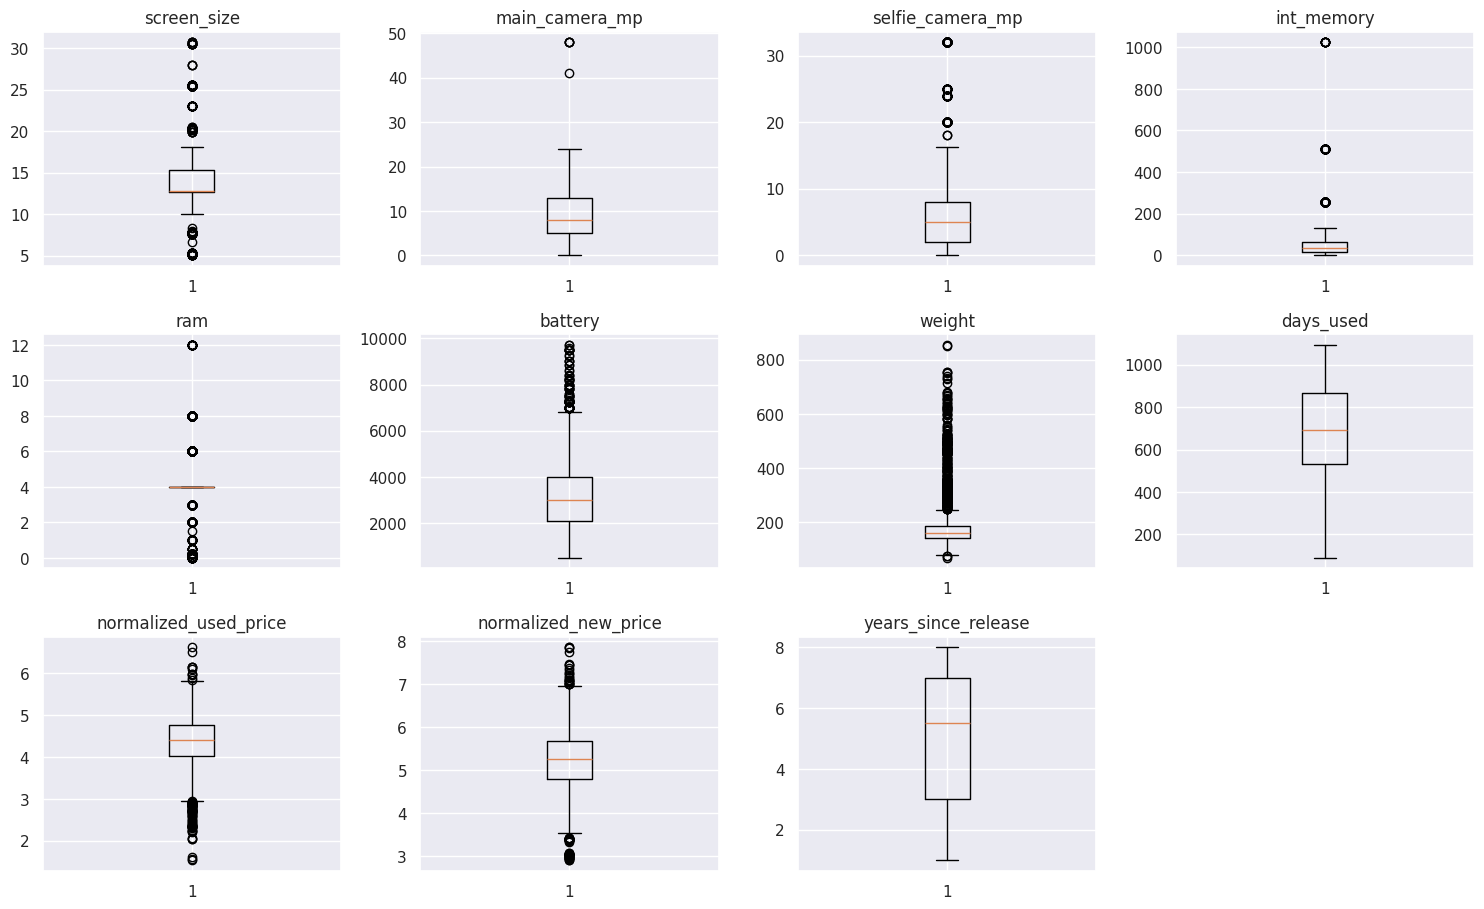

In [ ]:
plt.figure(figsize=(15, 12)) # create a plot with the size 15,12

# this code is a loop that creates a boxplot of the numeric columns on the same scale
for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(df_copy[variable])
    plt.tight_layout()
    plt.title(variable)

plt.show()

#### Observations:

* There are several outliers in the data.

* The following columns have outliers: screen_size, selfie_camera_mp, int_memory, ram, battery, weight, normalized_used_price, and normalized_new_price.

* A visual inspect shows that the 'weight' column has the most outliers.  

* These outliers are many and represent proper values in the dataset. Treating them will potentially affect the data, possibly causing skewness and impact any further analysis.

* 'days_used' and 'years_since_release' have no outliers.

### Data preparation for modeling

In [ ]:
# this code differentiates the independent (X) from the dependent (Y) variables
# target variable is 'normalized_used_price' hence it is dropped from  X
X = df_copy.drop(['normalized_used_price'], axis=1)
y = df_copy['normalized_used_price']

print(X.head())
print()
print(y.head())

  brand_name       os  screen_size   4g   5g  main_camera_mp  \
0      Honor  Android       14.500  yes   no          13.000   
1      Honor  Android       17.300  yes  yes          13.000   
2      Honor  Android       16.690  yes  yes          13.000   
3      Honor  Android       25.500  yes  yes          13.000   
4      Honor  Android       15.320  yes   no          13.000   

   selfie_camera_mp  int_memory   ram  battery  weight  days_used  \
0             5.000      64.000 3.000 3020.000 146.000        127   
1            16.000     128.000 8.000 4300.000 213.000        325   
2             8.000     128.000 8.000 4200.000 213.000        162   
3             8.000      64.000 6.000 7250.000 480.000        345   
4             8.000      64.000 3.000 5000.000 185.000        293   

   normalized_new_price  years_since_release  
0                 4.715                    1  
1                 5.519                    1  
2                 5.885                    1  
3           

In [ ]:
# this code adds the intercept to data
X = sm.add_constant(X)

In [ ]:
# this code creates dummy variables and assigns it to the variable 'X'
X = pd.get_dummies(X, columns=X.select_dtypes(include=["object", "category"]).columns.tolist(), drop_first=True)

X.head()

,const,screen_size,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,days_used,normalized_new_price,...,brand_name_Spice,brand_name_Vivo,brand_name_XOLO,brand_name_Xiaomi,brand_name_ZTE,os_Others,os_Windows,os_iOS,4g_yes,5g_yes
0,1.000,14.500,13.000,5.000,64.000,3.000,3020.000,146.000,127,4.715,...,False,False,False,False,False,False,False,False,True,False
1,1.000,17.300,13.000,16.000,128.000,8.000,4300.000,213.000,325,5.519,...,False,False,False,False,False,False,False,False,True,True
2,1.000,16.690,13.000,8.000,128.000,8.000,4200.000,213.000,162,5.885,...,False,False,False,False,False,False,False,False,True,True
3,1.000,25.500,13.000,8.000,64.000,6.000,7250.000,480.000,345,5.631,...,False,False,False,False,False,False,False,False,True,True
4,1.000,15.320,13.000,8.000,64.000,3.000,5000.000,185.000,293,4.948,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
# this code splits the data in a 70:30 ratio for training to test the data

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [ ]:
print("Number of rows in train data =", x_train.shape[0])
print("Number of rows in test data =", x_test.shape[0])

Number of rows in train data = 2417
Number of rows in test data = 1037


## Exploratory Data Analysis (EDA)

### Univariate Analysis

In [ ]:
# this code defines a function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize)
    # creates the boxplot and the histogram
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet") # creates a boxplot and uses a triangle to indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2)  # creates a histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--") # includes the mean
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-") # includes the median

In [ ]:
# this code defines a function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total) # gets the percentage
        else:
            label = p.get_height()  # gets the count of each level of the category

        x = p.get_x() + p.get_width() / 2  # sets the width of the plot
        y = p.get_height()  # sets the height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points") # annotate the percentage at the center for each bar

    plt.show()  # displays the plot

#### Brand Name

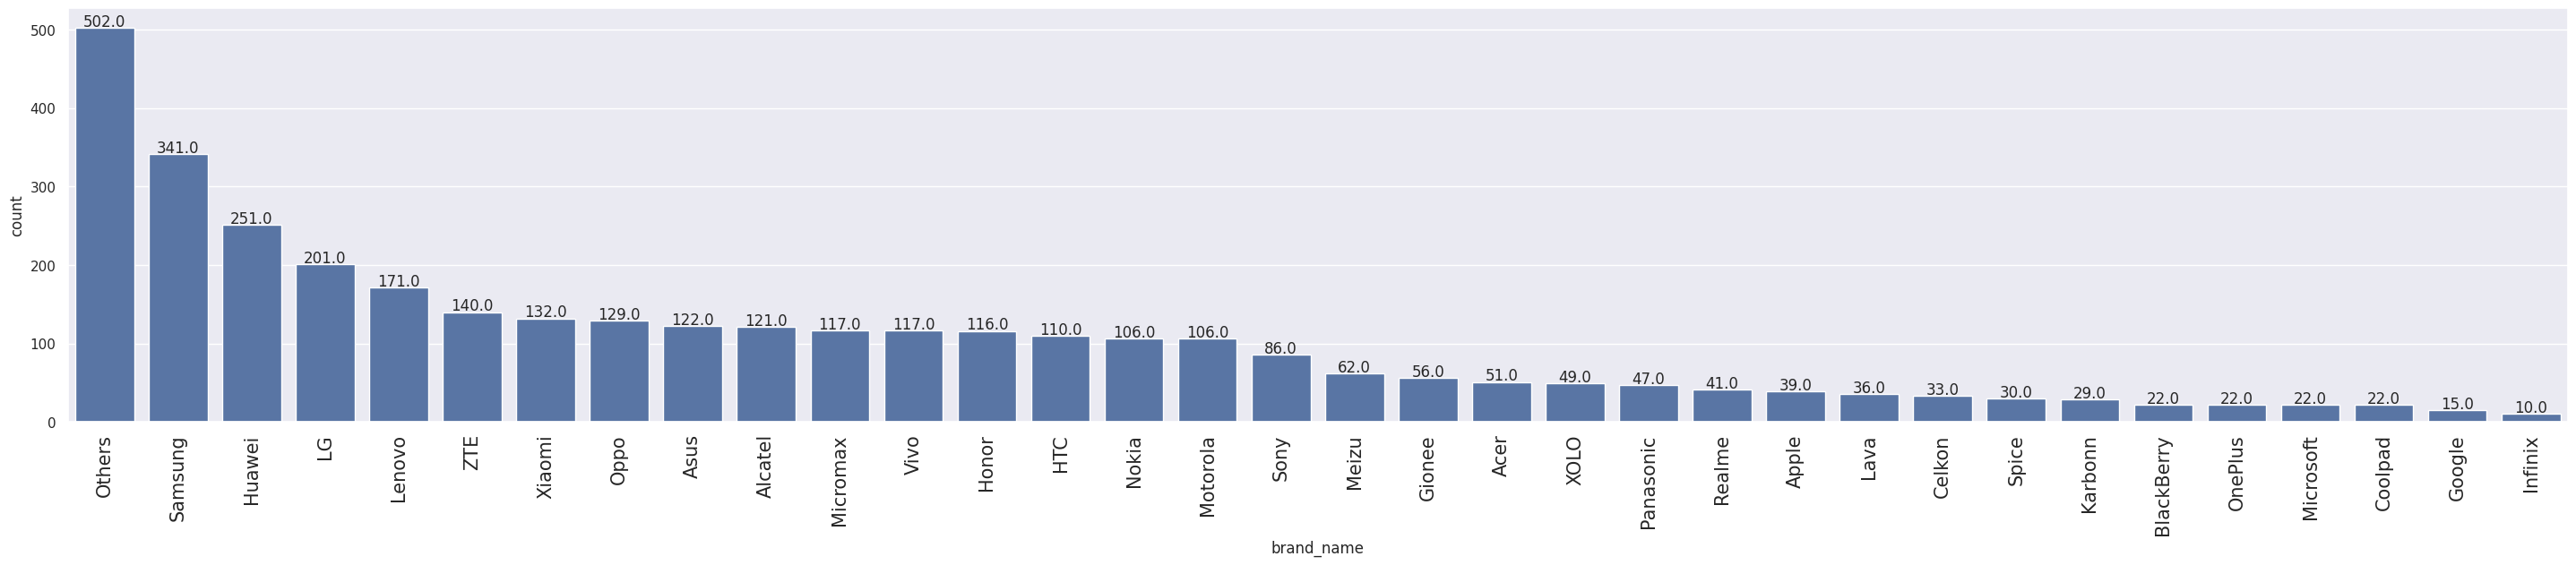

In [ ]:
labeled_barplot(df, "brand_name")  # displays a barplot for the 'brand_name' column

##### Observations:

* The group categorized as 'Others' have the most phones in the dataset - 502.

* This is followed by Samsung and Huawei with 341 and 251 respectively.

* The brand with the least phones in the dataset is Infinix.

#### Operating System (OS)

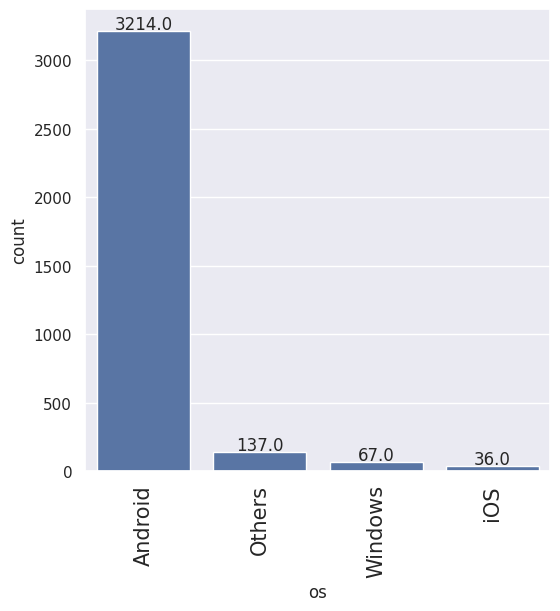

In [ ]:
labeled_barplot(df, "os")  # displays a barplot for the 'os' column

##### Observation:

* The operating system with the most phones is Andriod. It occurs over 90% of the data.

* IOS is the operating system with the least phones in the dataset.

#### Screen Size

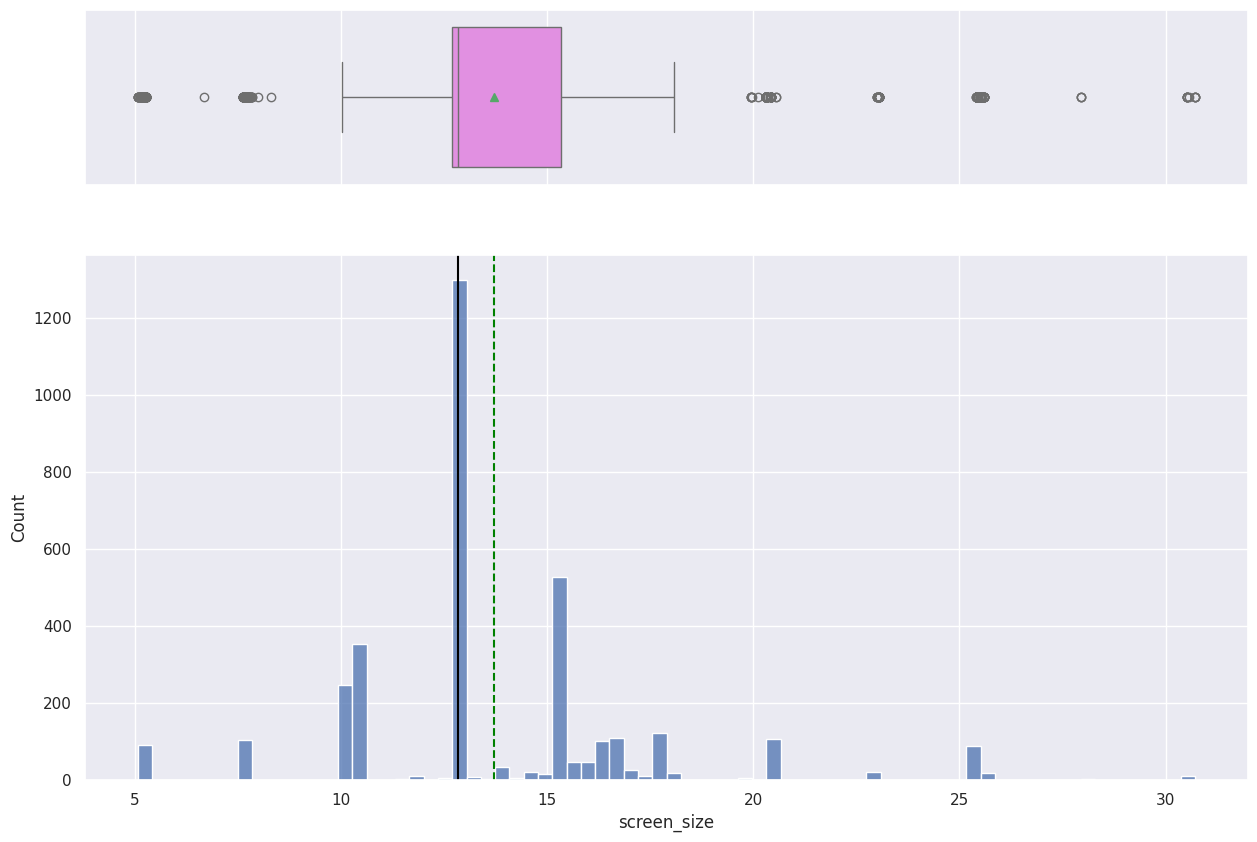

In [ ]:
histogram_boxplot(df, "screen_size")  # displays a barplot for the 'screen_size' column

##### Obervation:

* There are outliers on both the lower and upper ends of the whiskers.

* The average screen size is about 13.71 (confirming from the statistical summary at the beginning of this notebook)

#### 4G

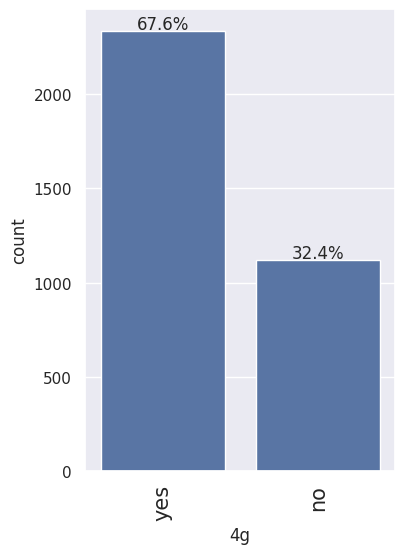

In [ ]:
labeled_barplot(df, "4g", perc=True)  # displays a barplot for the '4g' column

##### Observation:

* 67.6% of the phones, representing the majority have 4G network.

#### 5G

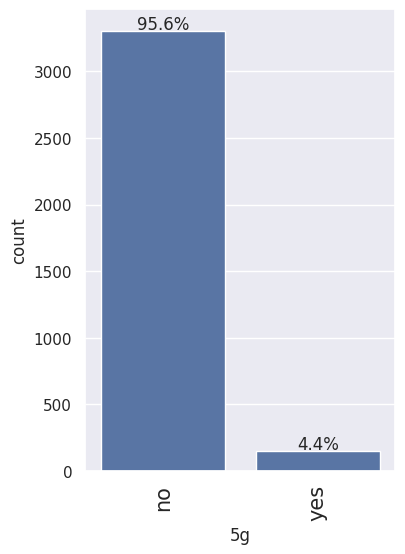

In [ ]:
labeled_barplot(df, "5g", perc=True)   # displays a barplot for the '5g' column

##### Observation:

* For 5G network, 95.6% of the phone do not have it available.

* Only 4.4% of the phones have 5G network.

#### Main Camera mp

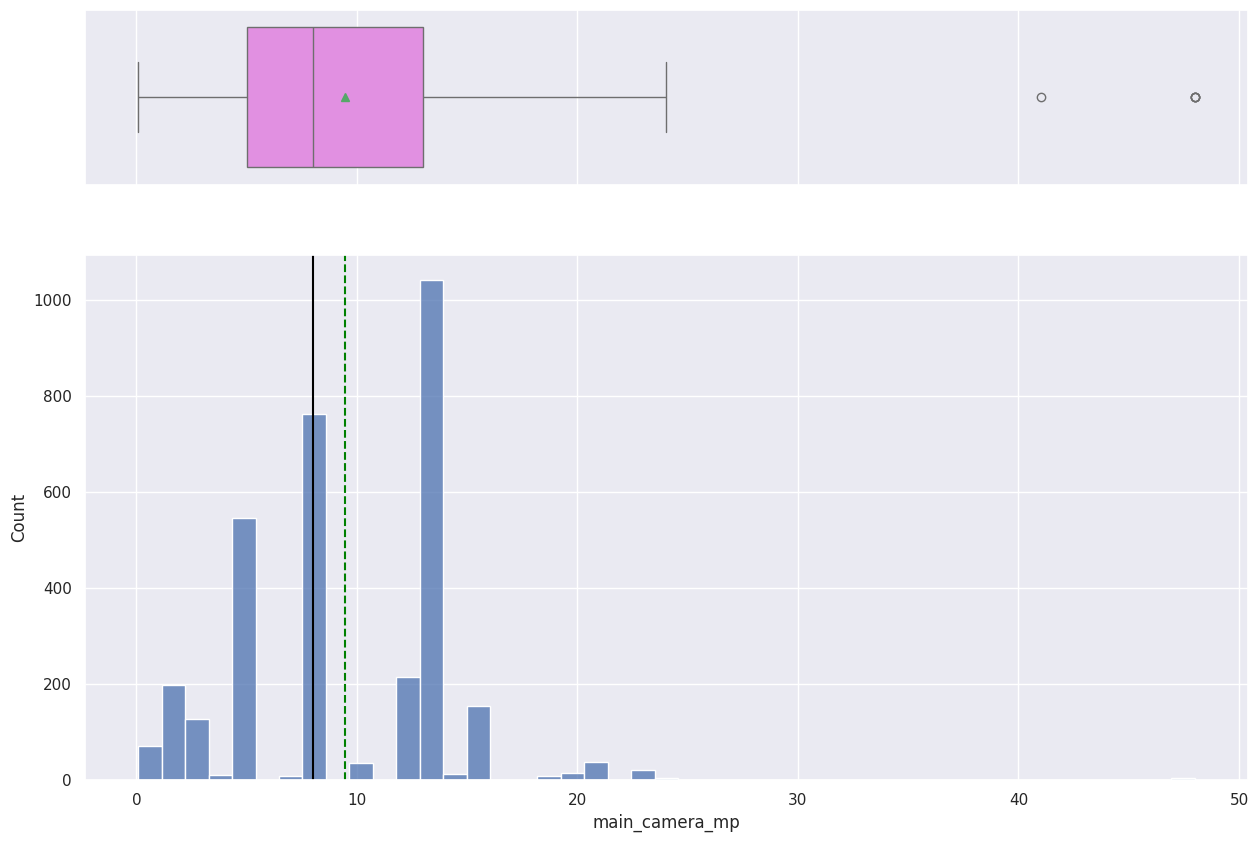

In [ ]:
histogram_boxplot(df, "main_camera_mp")   # displays a histogram and boxplot for the 'main_camera_mp' column

##### Observation:

* There are outliers on the upper whisker.

* The distribution of main_camera_mp appears to be positive skewed.

* The mean resolution is 9.46 (confirmed from the statisticall summary in the preceeding cells).

#### Selfie Camera mp

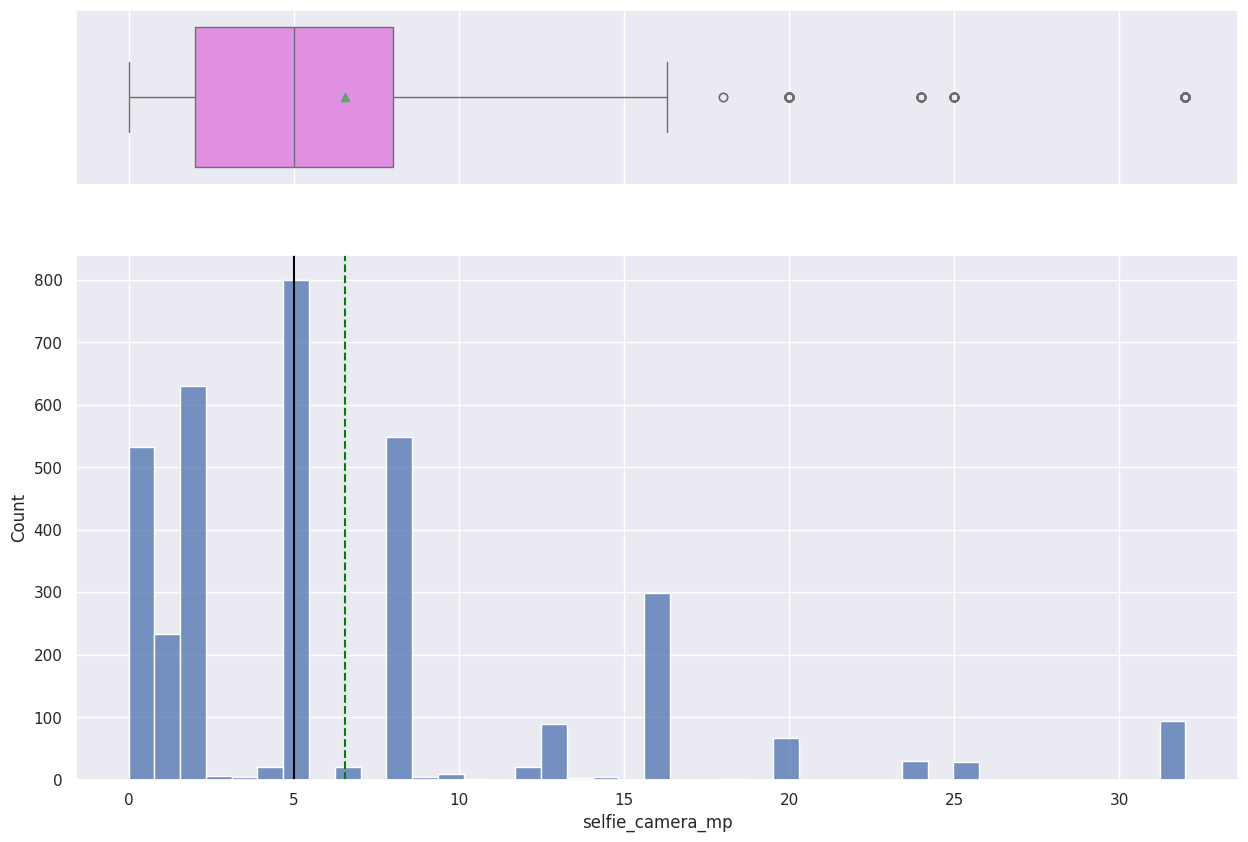

In [ ]:
histogram_boxplot(df, "selfie_camera_mp")   # displays a histogram and boxplot for the 'selfie_camera_mp' column

##### Observation:

* There are outliers on the upper whisker.

* The mean resolution is 6.55 (confirmed from the statisticall summary in the preceeding cells).

#### Internal Memory

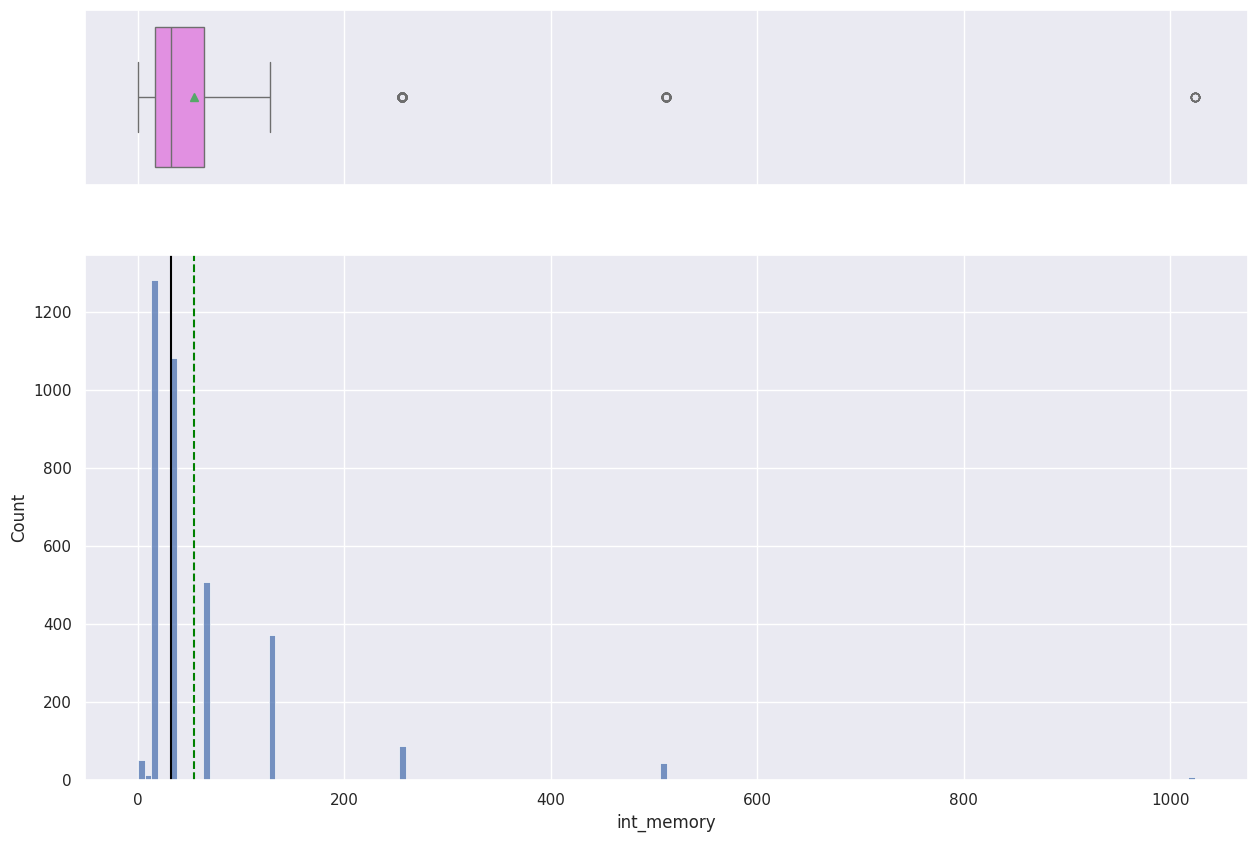

In [ ]:
histogram_boxplot(df, "int_memory") # displays a histogram and boxplot for the 'int_memory' column

##### Observation:

* There are few outliers on the upper whisker.

* The distribution of internal memory appears to be positive skewed.

#### RAM

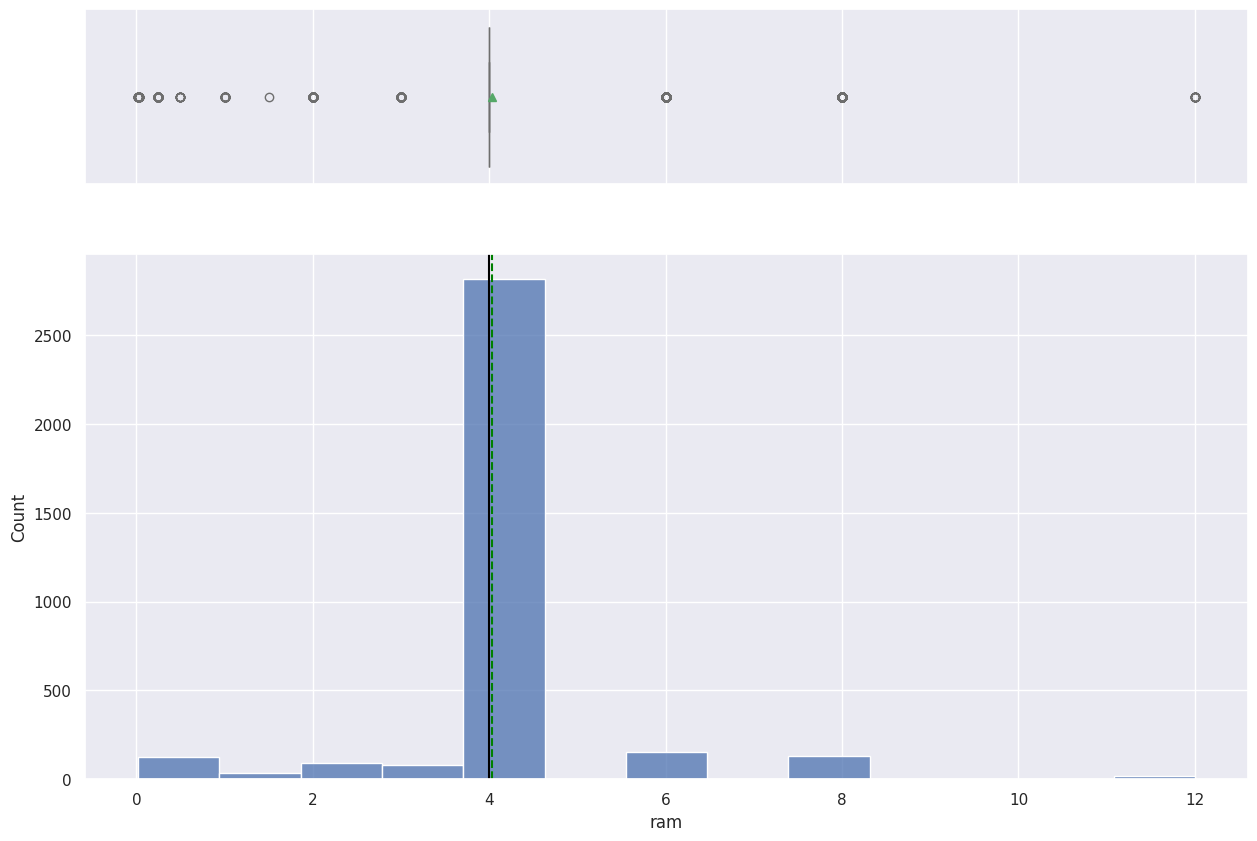

In [ ]:
histogram_boxplot(df, "ram")  # displays a histogram and boxplot for the 'ram' column

##### Observation:

* There are some outliers in the data.

* The average RAM size is 4.04GB (confirmed from the statistical summary presented at the beginning on this notebook).

#### Battery

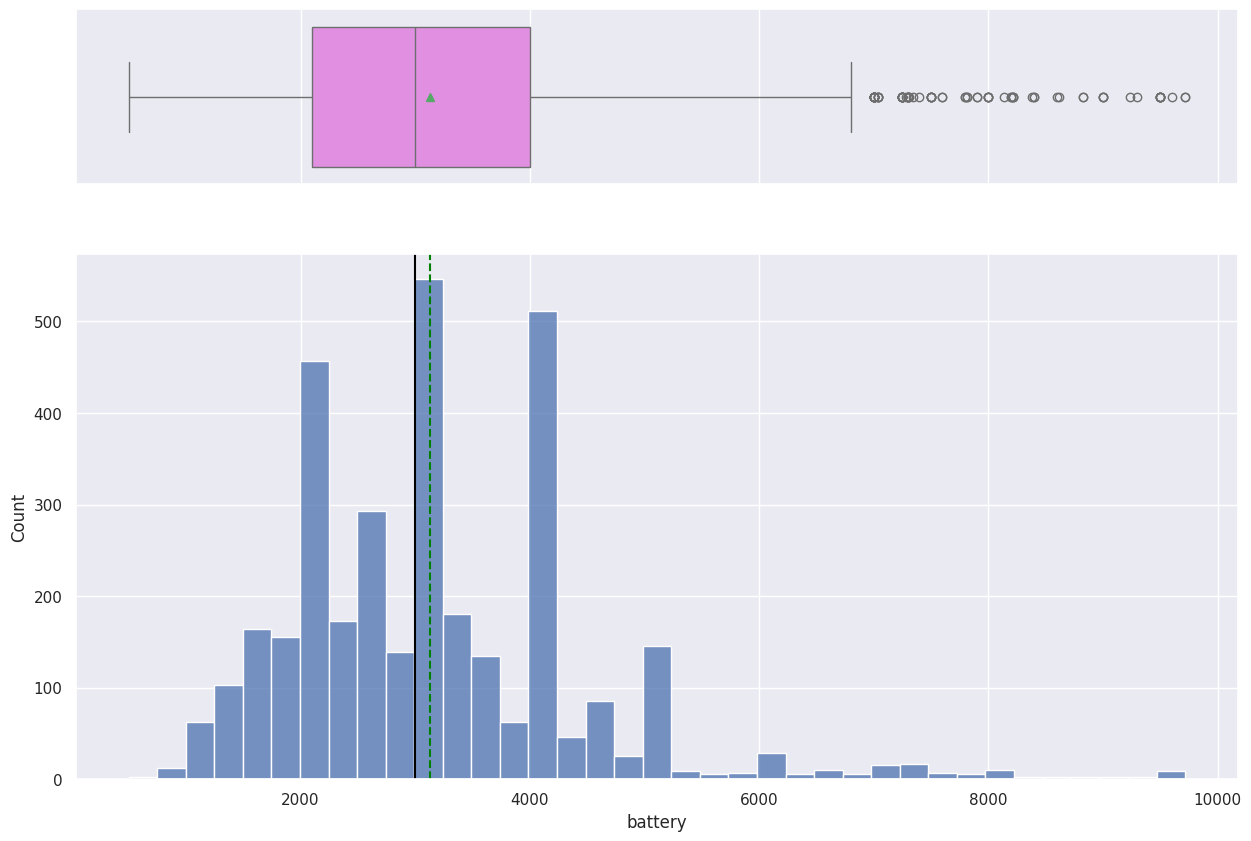

In [ ]:
histogram_boxplot(df, "battery")  # displays a histogram and boxplot for the 'battery' column

##### Observation:

* There are outliers on the upper whisker.

* The average battery capacity is 3133.40 mAH (confirmed from the statistical sumary).

#### Weight

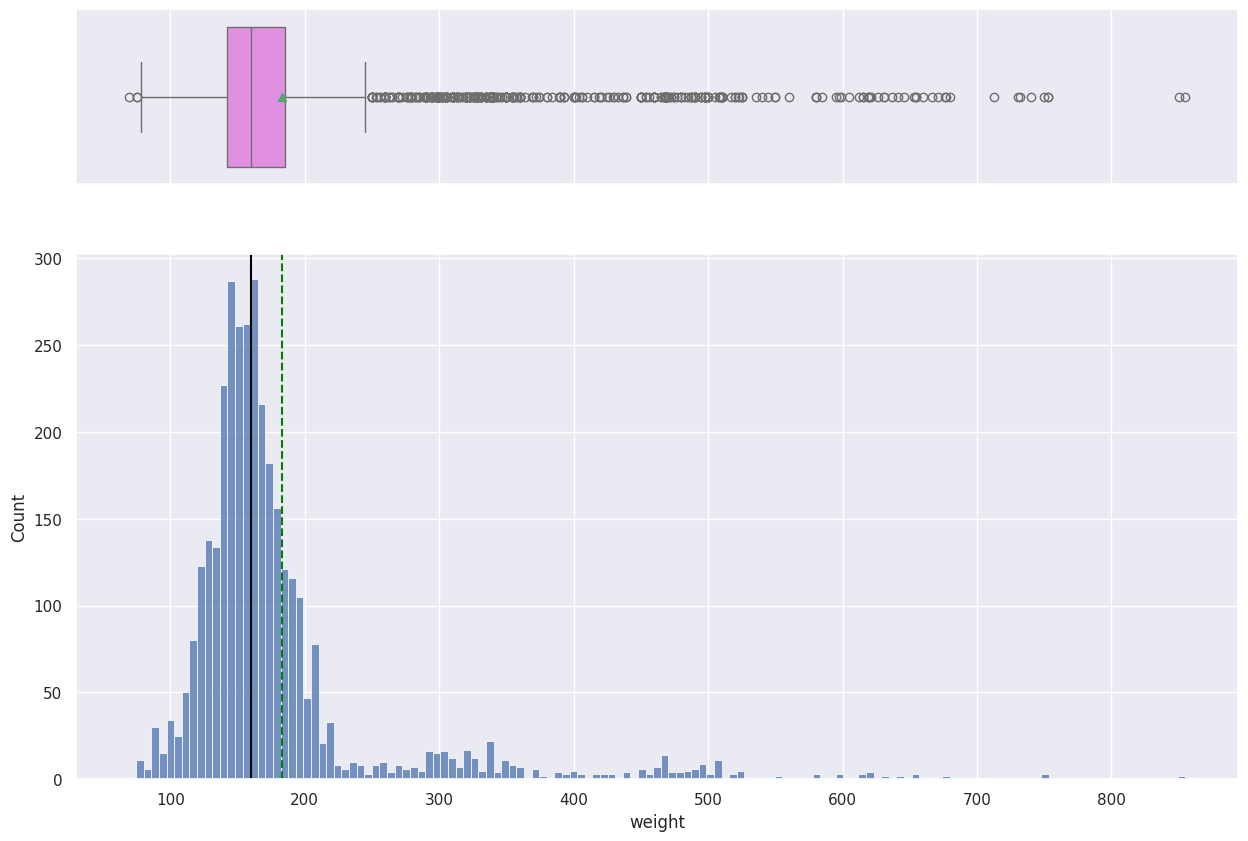

In [ ]:
histogram_boxplot(df, "weight")  # displays a histogram and boxplot for the 'weight' column

##### Observation:

* At first glance, 'weight' appears to be normally distributed however careful visual inspection shows that it is slight positive skewed.

* There are several outliers on the upper side of the whisker.

* The avearage weight is 182.75 (confirmed for the statistical summary.

#### Release Year

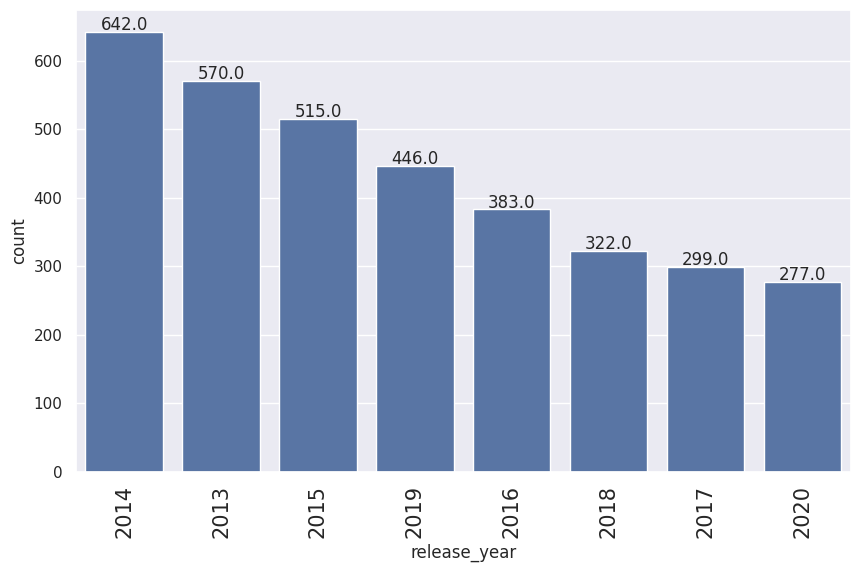

In [ ]:
labeled_barplot(df, "release_year")  # displays a histogram and boxplot for the 'release_year' column

##### Observation:
* Majority (642) of the phones in this dataset were released in 2014.

* This is closely followed by 2013 and 2015 with 570 and 515 phones respectively.

* 2020 recorded the least number of phones released.

#### Days Used

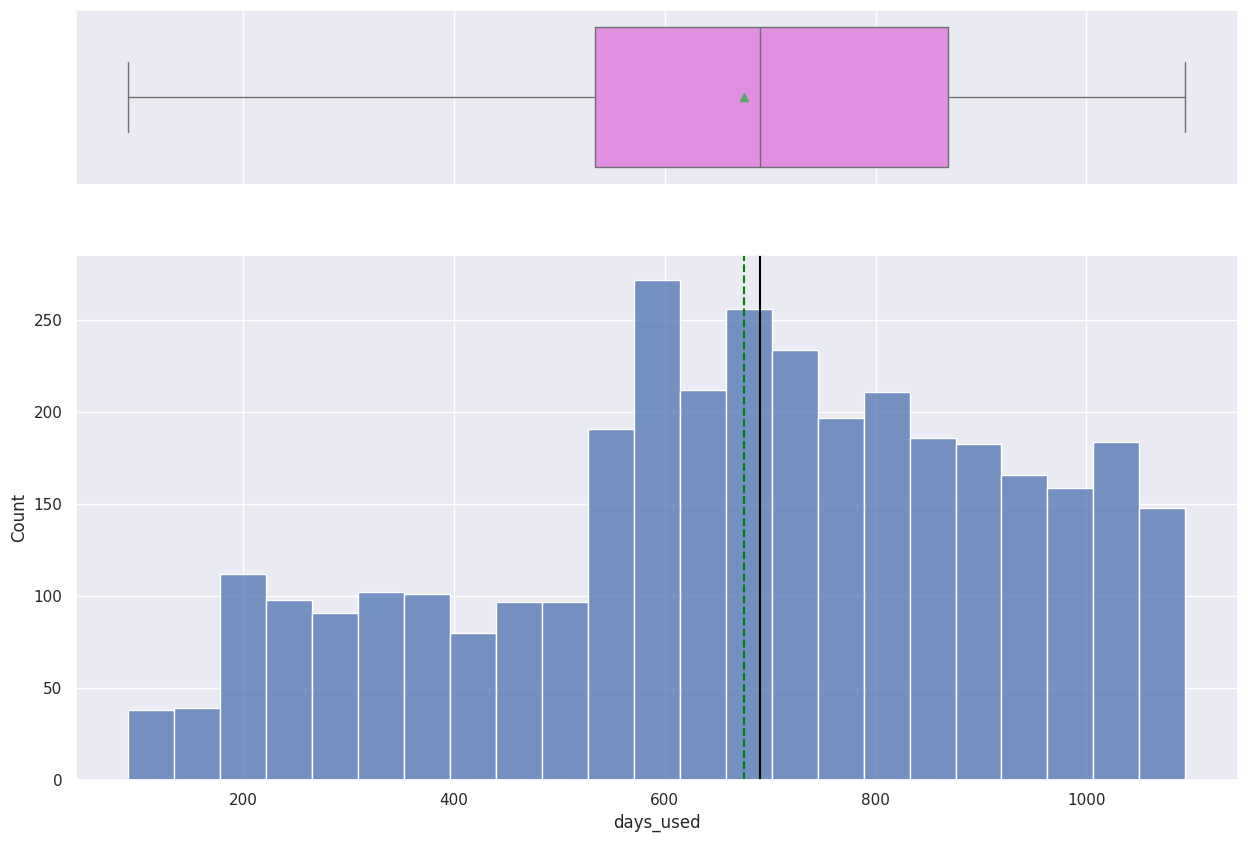

In [ ]:
histogram_boxplot(df, "days_used")  # displays a histogram and boxplot for the 'days_used' column

##### Observation:

* There appears to be no outliers in the dataset.

* The mean days used is 674.87.

* The distribute appears to be very slighty negative skew.

#### Normalized New Price

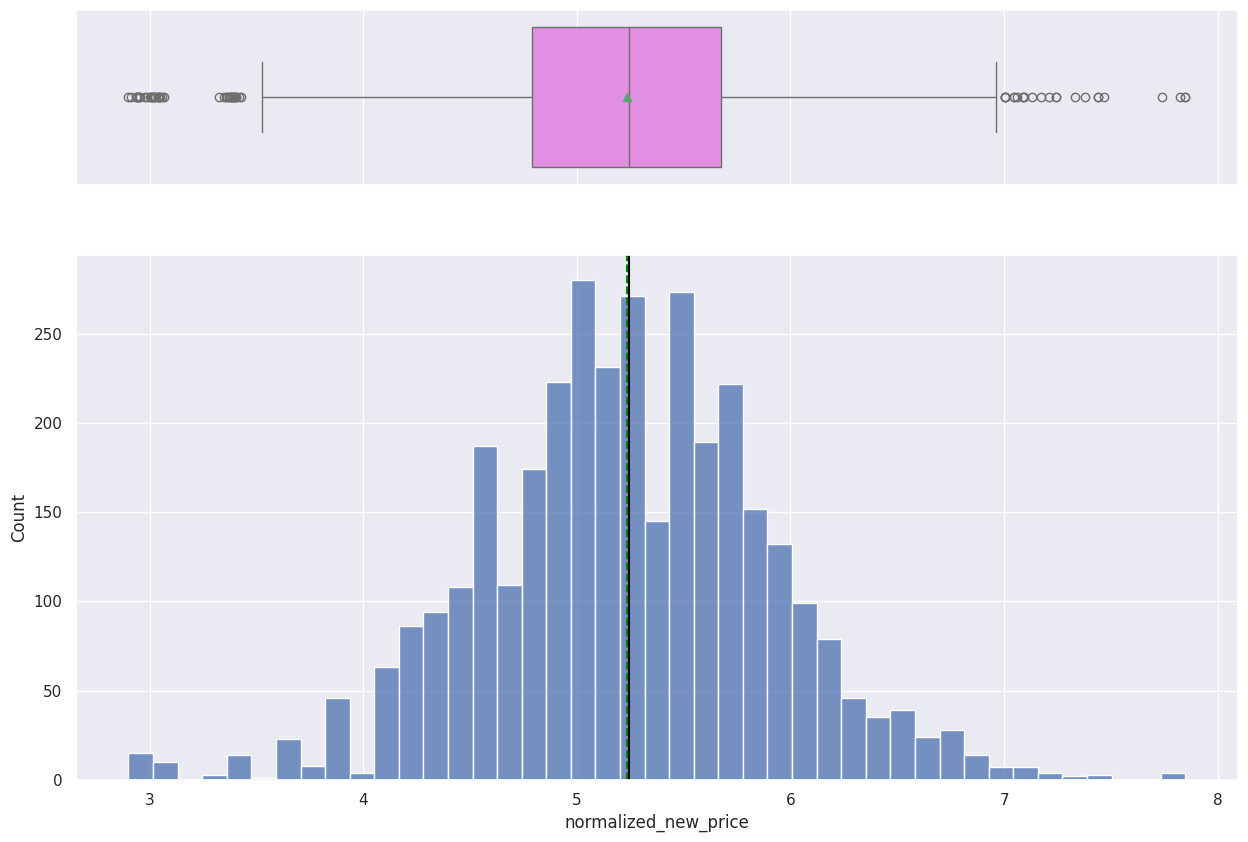

In [ ]:
histogram_boxplot(df, "normalized_new_price") # displays a histogram and boxplot for the'normalized_new_price' column

##### Observation:

* There are outliers on both sides of the whiskers.

* Normalized new price appears to be normally distributed.

* The mean normalised price for used phones is 5.23.

#### Normalize Used Price

* To find the distribution of prices of 'normalised_used_devices', several plots will be used to visualise the data.
The statistical summary in the above section already showed the descriptive statistics. These are:
    * **Mean**: 4.365,
    * **Standard Deviation**: 0.589,
    * **Minimum value**: 1.537,
    * **Maximum value**: 6.619,
    * **25%**: 4.034,
    * **50%**: 4.405,
    * **75%**: 4.756.
* The skewness and kurtosis will be calculated in order to better understand the distribution.  

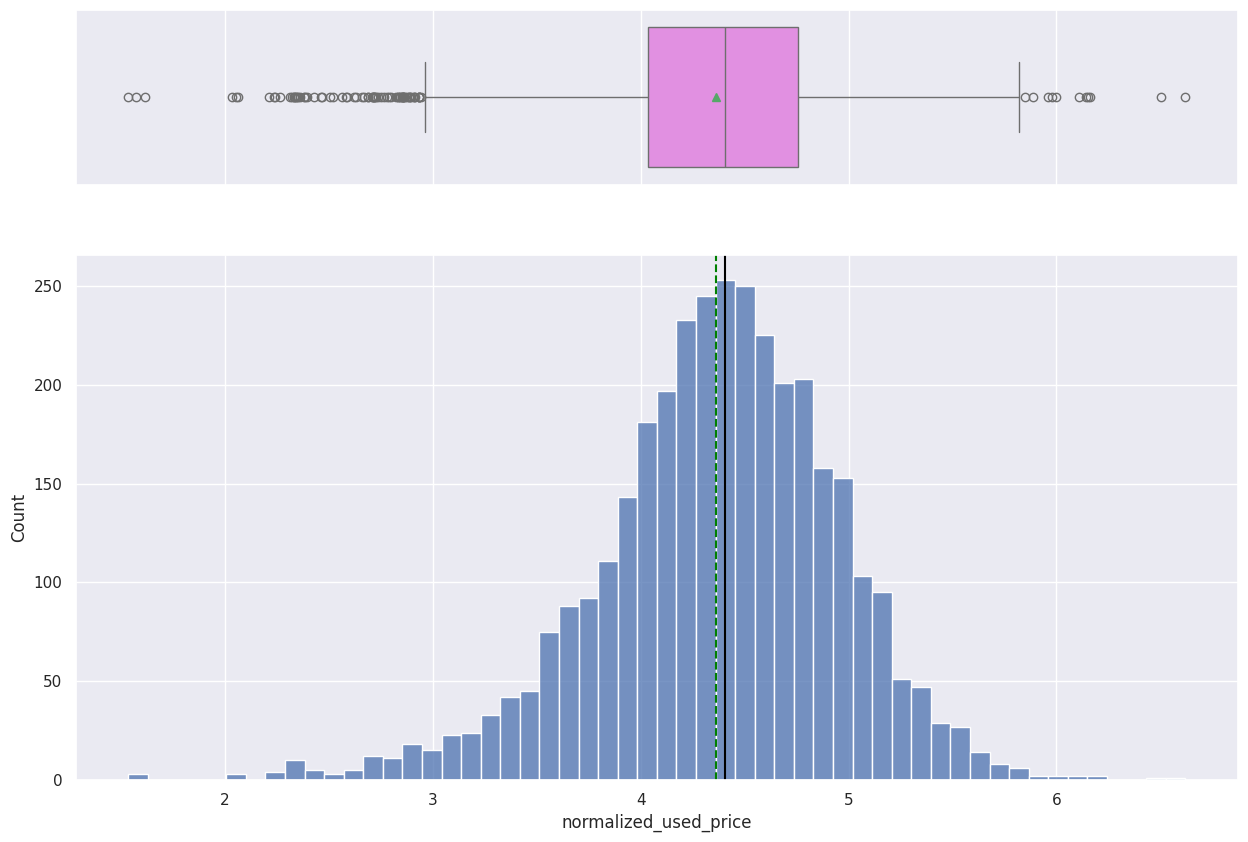

In [ ]:
histogram_boxplot(df, "normalized_used_price")

In [ ]:
# this code calculates the skewness and kurtosis of 'normalized_used_price'
skewness = df['normalized_used_price'].skew()
kurtosis = df['normalized_used_price'].kurt()
print(f"\nSkewness: {skewness:.4f}")
print(f"Kurtosis: {kurtosis:.4f}")


Skewness: -0.5323
Kurtosis: 1.1788


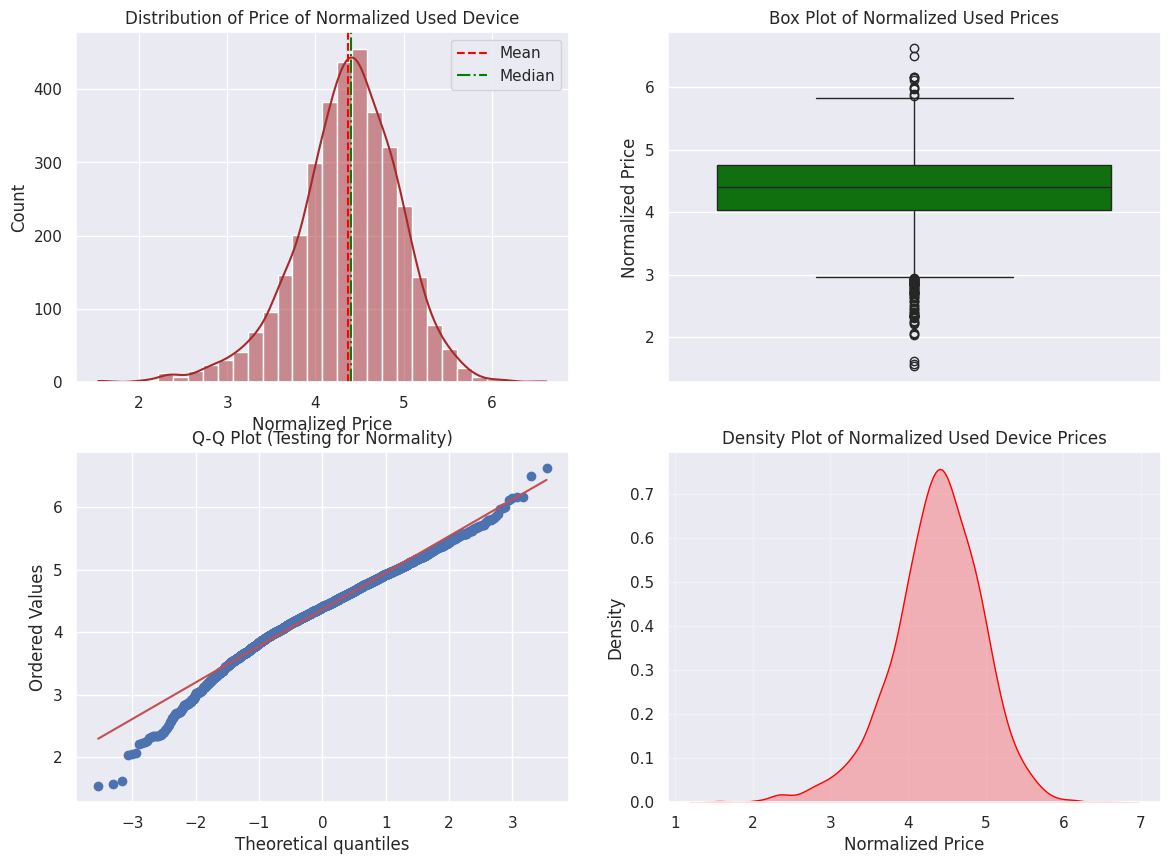

In [ ]:
# 4 plot to visualize the distribution of 'normalized_used_price'

plt.figure(figsize=(14, 10)) # creates a plot with the size 14, 10

# this code creates a histogram with KDE
plt.subplot(2, 2, 1)
sns.histplot(df['normalized_used_price'], kde=True, bins=30, color = 'brown')
plt.title('Distribution of Price of Normalized Used Device')
plt.xlabel('Normalized Price')
plt.axvline(df['normalized_used_price'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['normalized_used_price'].median(), color='green', linestyle='-.', label='Median')
plt.legend()

# this code creates a Box plot
plt.subplot(2, 2, 2)
sns.boxplot(y=df['normalized_used_price'], color = 'green')
plt.title('Box Plot of Normalized Used Prices')
plt.ylabel('Normalized Price')

# this code creates a Q-Q plot to check normality
plt.subplot(2, 2, 3)
stats.probplot(df['normalized_used_price'].dropna(), dist="norm", plot=plt)
plt.title('Q-Q Plot (Testing for Normality)')


# this code creates a kdeplot to make the shape of the distribution clear
plt.subplot(2, 2, 4)
sns.kdeplot(df['normalized_used_price'], fill=True, color = 'red')
plt.title('Density Plot of Normalized Used Device Prices')
plt.xlabel('Normalized Price')
plt.grid(True, alpha=0.3)
plt.show()

##### Observation:

* There are several outliers on both sides of the whiskers.

* The normalized price of used phones is normaly distributed.

### Bivariate Analysis

#### Percentage distribution of used Andriod devices on the market.

In [ ]:
os_counts = df['os'].value_counts().reset_index()
os_counts.columns = ['Operating System', 'Count']

# Calculate percentages
total_devices = os_counts['Count'].sum()
os_counts['Percentage'] = (os_counts['Count'] / total_devices * 100).round(2)

# Display the results
print("Market Share by Operating System:")
print(os_counts)

# Extract Android percentage
android_percentage = os_counts[os_counts['Operating System'] == 'Android']['Percentage'].values[0] \
    if 'Android' in os_counts['Operating System'].values else 0

print(f"\nAndroid's share of the used device market: {android_percentage}%")

Market Share by Operating System:
  Operating System  Count  Percentage
0          Android   3214      93.050
1           Others    137       3.970
2          Windows     67       1.940
3              iOS     36       1.040

Android's share of the used device market: 93.05%


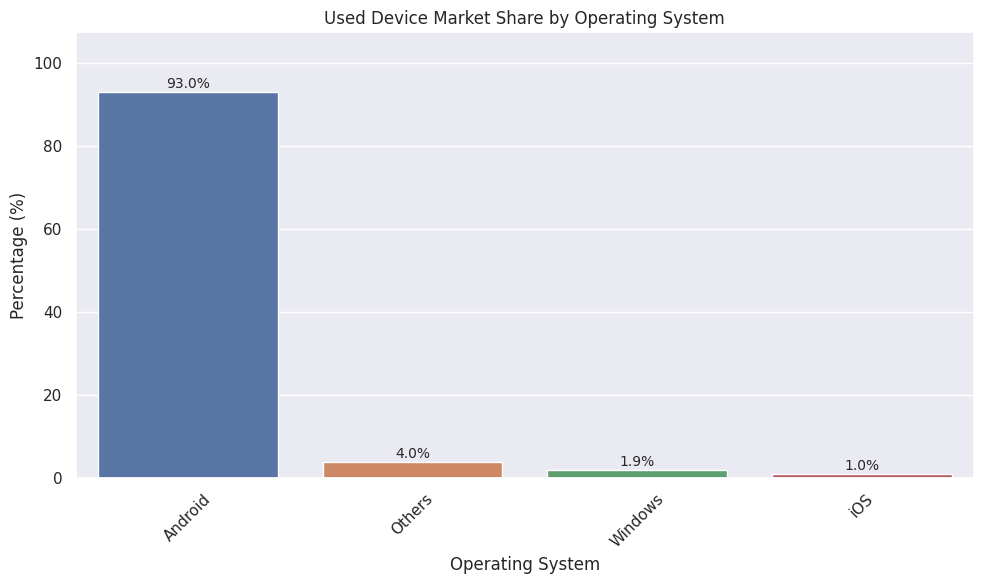

In [ ]:
# Bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Operating System', y='Percentage', hue='Operating System', data=os_counts)
plt.title('Used Device Market Share by Operating System')
plt.ylabel('Percentage (%)')
plt.xlabel('Operating System')
plt.xticks(rotation=45)

# Add percentage labels on top of each bar
for i, percentage in enumerate(os_counts['Percentage']):
    plt.text(i, percentage + 1, f'{percentage:.1f}%', ha='center', fontsize=10)

# Remove the legend since it's redundant (hue and x-axis show the same information)
plt.legend([],[], frameon=False)

# Adjust y-axis to make room for the labels
current_ylim = plt.ylim()
plt.ylim(0, current_ylim[1] * 1.1)  # Add 10% more space at the top

plt.tight_layout()
plt.show()

##### Observation:

* Used android devices has the majority share of 93% on the market.

#### Distribution of RAM by brand.

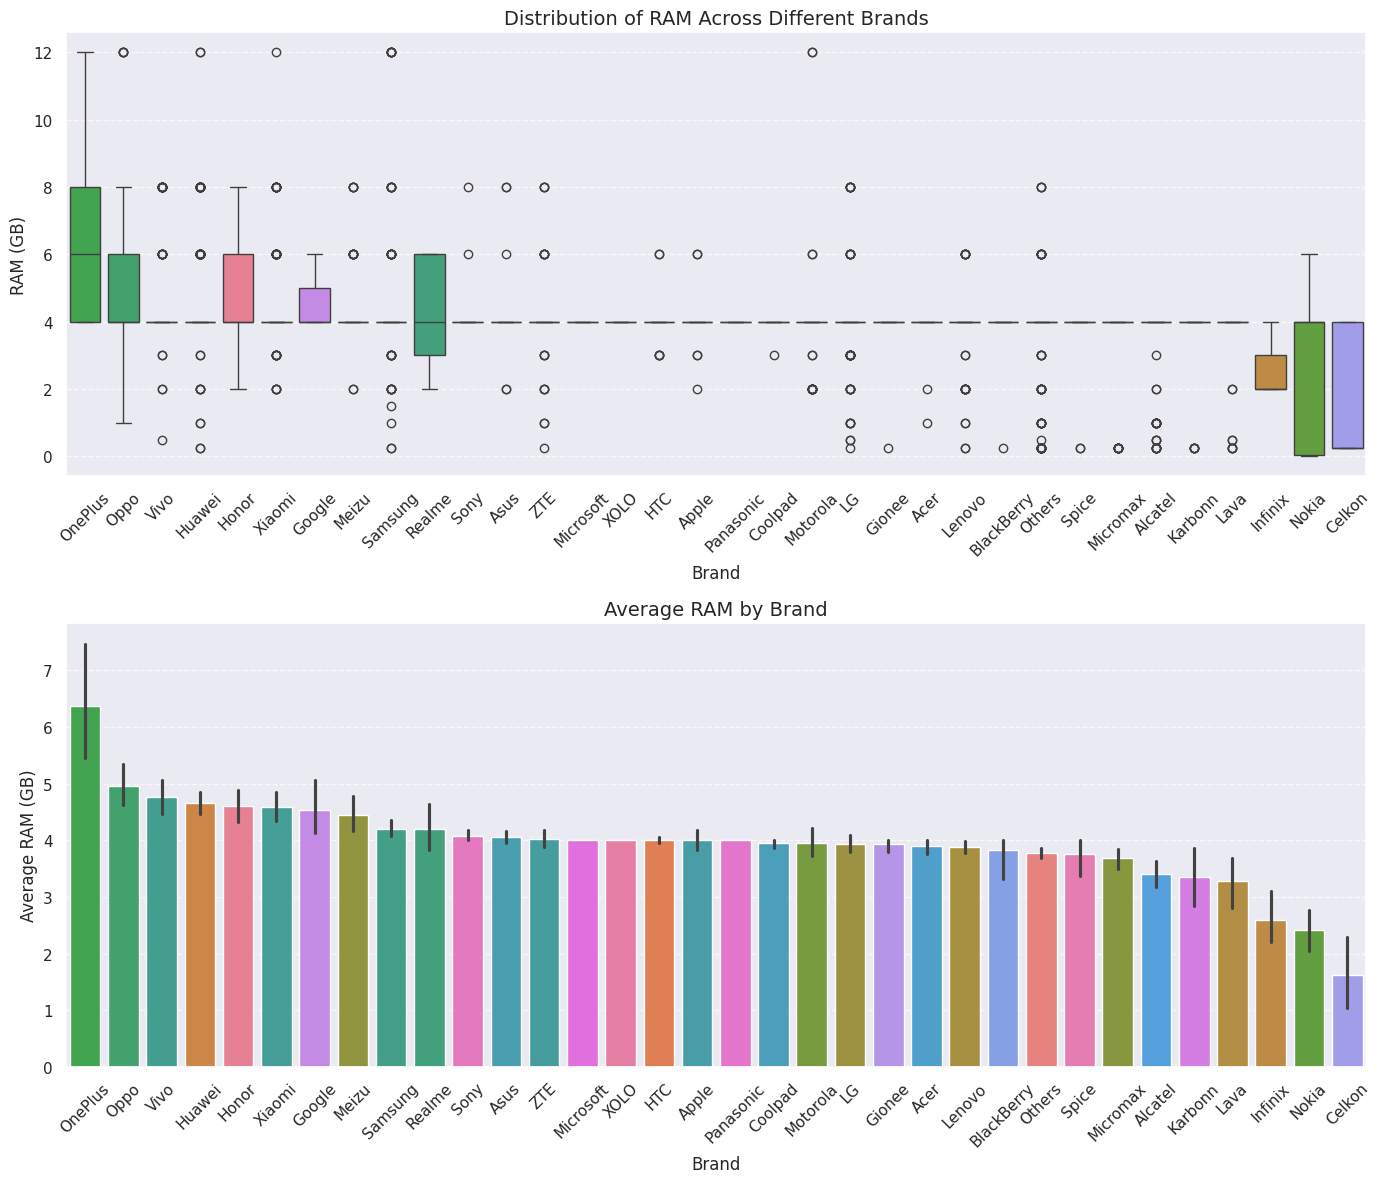

In [ ]:
# Calculate key statistics of RAM by brand
ram_by_brand = df.groupby('brand_name')['ram'].agg(['mean', 'median', 'min', 'max', 'std', 'count'])
ram_by_brand = ram_by_brand.sort_values(by='mean', ascending=False)  # Sort by mean RAM

# Create visualizations to show how RAM varies with brand
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Boxplot showing distribution of RAM across brands
sns.boxplot(x='brand_name', y='ram', hue='brand_name', data=df, order=ram_by_brand.index, ax=axes[0])
axes[0].set_title('Distribution of RAM Across Different Brands', fontsize=14)
axes[0].set_xlabel('Brand', fontsize=12)
axes[0].set_ylabel('RAM (GB)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Bar chart showing average RAM by brand -
sns.barplot(x='brand_name', y='ram', hue='brand_name', data=df,
            estimator=np.mean, order=ram_by_brand.index,
            legend=False, ax=axes[1])
axes[1].set_title('Average RAM by Brand', fontsize=14)
axes[1].set_xlabel('Brand', fontsize=12)
axes[1].set_ylabel('Average RAM (GB)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

##### Observations:

* There are outliers in each distribution of RAM based on brand.

* Oneplus has the high RAM size while Celkron has the least RAM size.

#### Weight variation for phones and tablets offering large batteries (more than 4500 mAh).

Weight statistics for devices with batteries > 4500 mAh:
count   341.000
mean    332.276
std     155.502
min     118.000
25%     198.000
50%     300.000
75%     467.000
max     855.000
Name: weight, dtype: float64


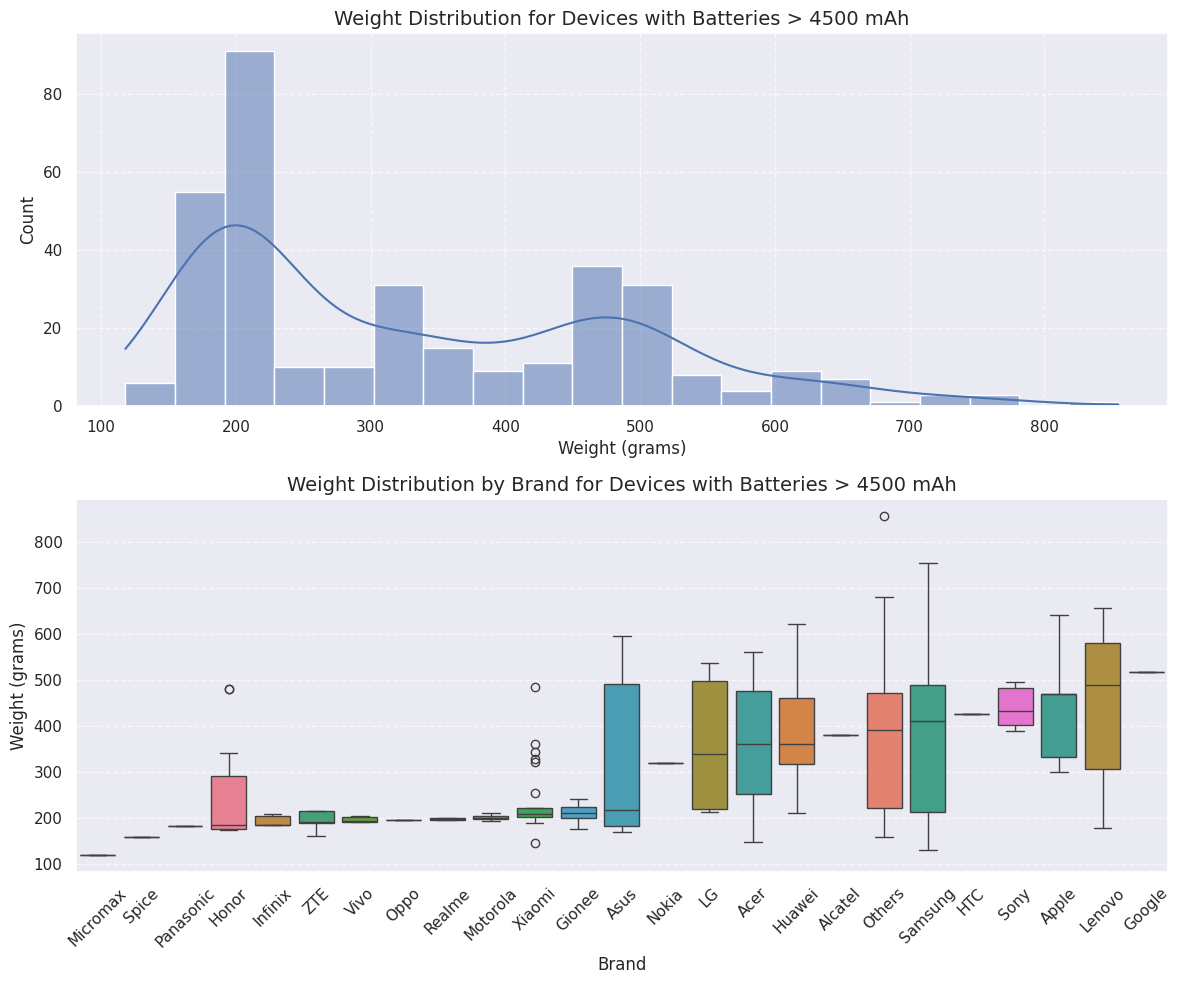

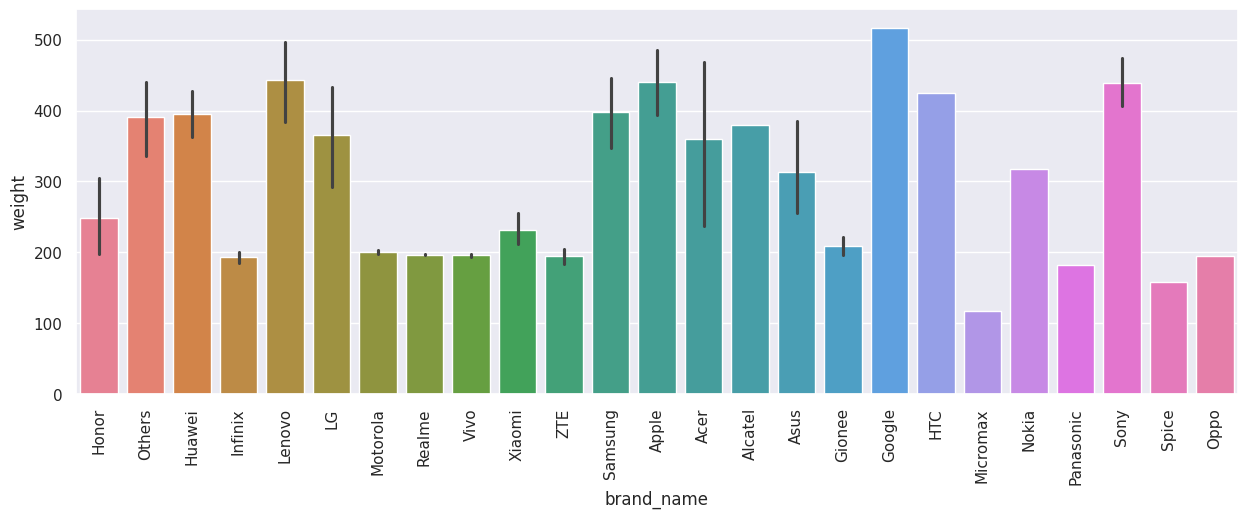

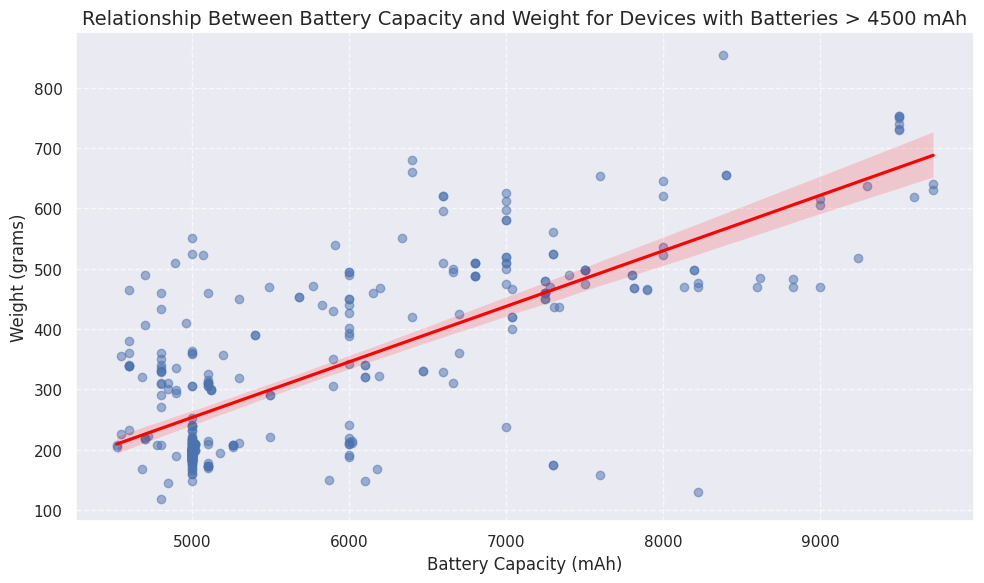


Correlation between battery capacity and weight for devices with large batteries: 0.7576


In [ ]:
# Filter the dataset for devices with large batteries (>4500 mAh)
large_battery_devices = df[df['battery'] > 4500].copy()

# Basic statistics about weight for large battery devices
print("Weight statistics for devices with batteries > 4500 mAh:")
weight_stats = large_battery_devices['weight'].describe()
print(weight_stats)

# Visualize the weight distribution for large battery devices
plt.figure(figsize=(12, 10))

# Histogram of weight for large battery devices
plt.subplot(2, 1, 1)
sns.histplot(large_battery_devices['weight'], bins=20, kde=True)
plt.title('Weight Distribution for Devices with Batteries > 4500 mAh', fontsize=14)
plt.xlabel('Weight (grams)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Boxplot of weight by brand for large battery devices
plt.subplot(2, 1, 2)
# Sort brands by their median weight
brand_order = large_battery_devices.groupby('brand_name')['weight'].median().sort_values().index

# Creates the boxplot
sns.boxplot(x='brand_name', y='weight', hue='brand_name', data=large_battery_devices, order=brand_order)
plt.title('Weight Distribution by Brand for Devices with Batteries > 4500 mAh', fontsize=14)
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Weight (grams)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))
sns.barplot(x='brand_name', y='weight', hue='brand_name', data=large_battery_devices)
plt.xticks(rotation=90)
plt.show()

# Check for a relationship between battery size and weight
# within the large battery category
plt.figure(figsize=(10, 6))
sns.regplot(x='battery', y='weight', data=large_battery_devices,
           scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relationship Between Battery Capacity and Weight for Devices with Batteries > 4500 mAh', fontsize=14)
plt.xlabel('Battery Capacity (mAh)', fontsize=12)
plt.ylabel('Weight (grams)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Calculate correlation between battery and weight for large battery devices
correlation = large_battery_devices[['battery', 'weight']].corr().iloc[0, 1]
print(f"\nCorrelation between battery capacity and weight for devices with large batteries: {correlation:.4f}")

##### Observations:

* The brand with the heaviest devices is Google and the brand with the lightest devices is Micromax.

* A few of the brand distributions (Honor, Xiaomi and Others) for the weight have outliers.

* Phones with a battery size >4500mAH is positively correlated with weight.

#### Number of phones and tablets available across different brands with a screen size larger than 6 inches.

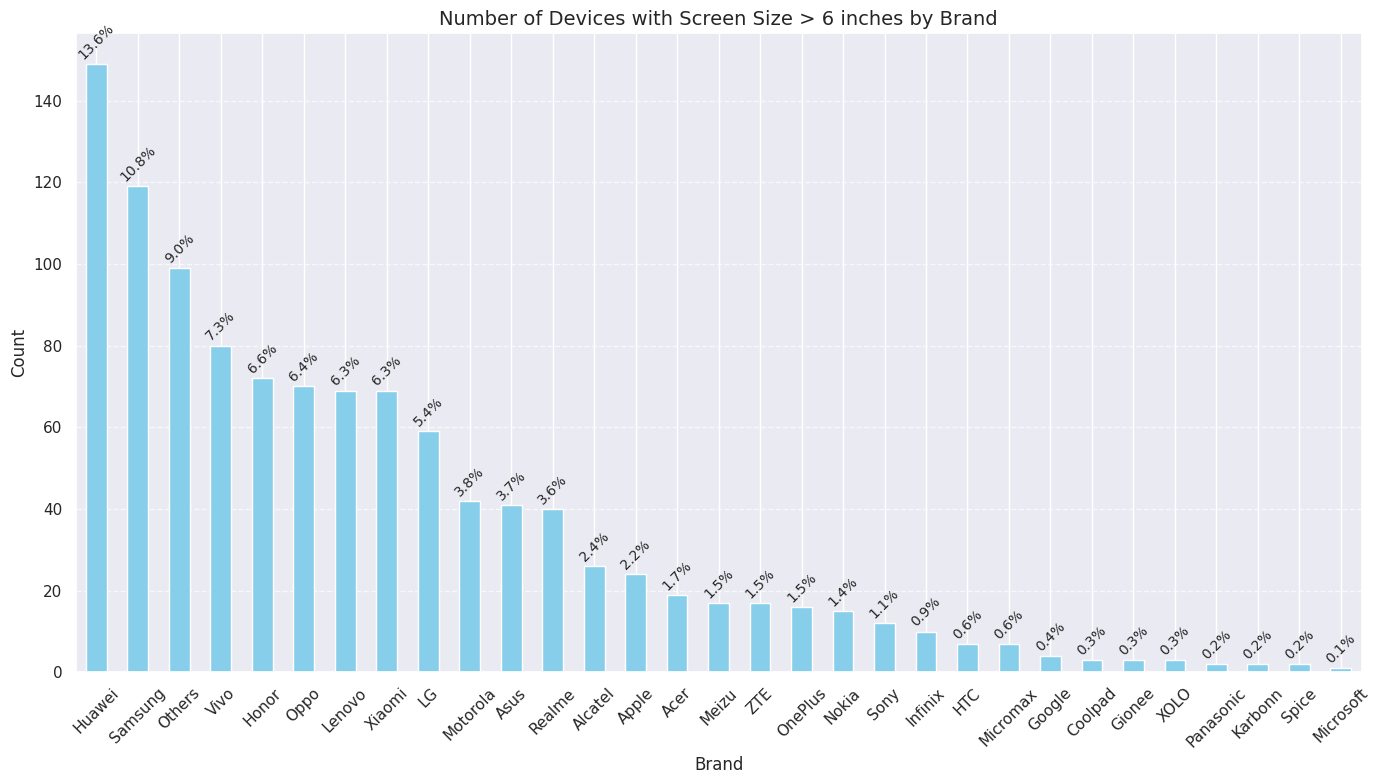

In [ ]:
# Converts 6 inches to centimeters
inches_6 = 6 * 2.54  # = 15.24 cm

# Filters the dataset for devices with screen size > 6 inches
large_screen_devices = df[df['screen_size'] > inches_6].copy()

# Counts the number of devices by brand
brand_counts = large_screen_devices['brand_name'].value_counts().sort_values(ascending=False)
total_large_screen = len(large_screen_devices)

# Calculates the percentages
brand_percentages = (brand_counts / total_large_screen * 100).round(1)

# Creates a bar chart with rotated percentage labels
plt.figure(figsize=(14, 8))

# Create the bar plot
ax = brand_counts.plot(kind='bar', color='skyblue')
plt.title('Number of Devices with Screen Size > 6 inches by Brand', fontsize=14)
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add rotated percentage labels on top of each bar
for i, percentage in enumerate(brand_percentages.values):
    # Position the text at the top of each bar
    height = brand_counts.values[i]
    # Add rotated percentage labels
    plt.text(i, height + 0.5, f"{percentage}%",
             ha='center', va='bottom', fontsize=10,
             rotation=45)  # Rotate text 90 degrees

plt.tight_layout()
plt.show()

##### Observations:

* Huawei has the most devices with screen sizes larger than 6 inches. This is about 13.6% of the market.

* This is followed by Samsung and Other with market shares of 10.8% and 9%, respectively.

* Microsoft has the least devices with screen sizes larger than 6 inches.

#### Distribution of devices offering greater than 8MP selfie cameras across brands.

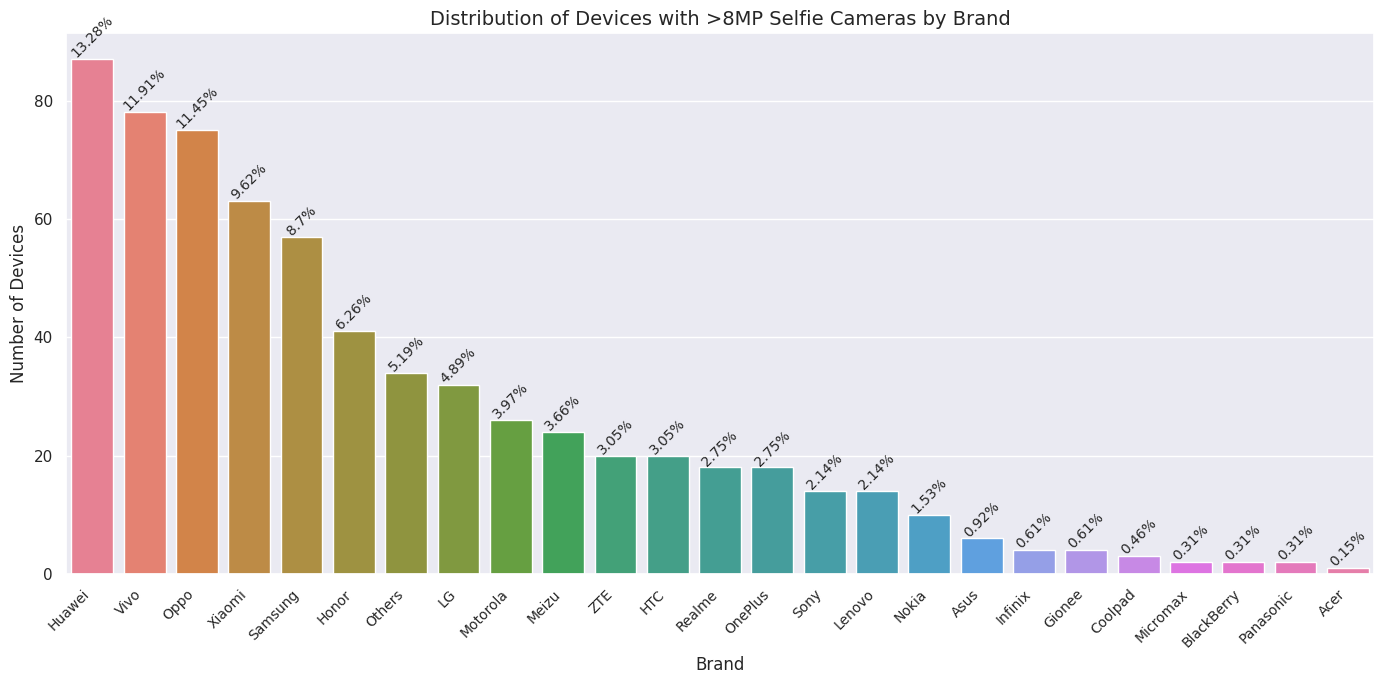

In [ ]:
# Filters the data for devices with selfie cameras > 8MP
high_mp_selfies = df[df['selfie_camera_mp'] > 8]

# Groups by brand and count devices
brand_distribution = high_mp_selfies['brand_name'].value_counts().reset_index()
brand_distribution.columns = ['Brand', 'Number of Devices']

# Calculates the percentage distribution
total_devices = brand_distribution['Number of Devices'].sum()
brand_distribution['Percentage'] = (brand_distribution['Number of Devices'] / total_devices * 100).round(2)

# Sorts by number of devices in descending order
brand_distribution = brand_distribution.sort_values('Number of Devices', ascending=False)

# Visualizes the results
plt.figure(figsize=(14, 7))
ax = sns.barplot(x='Brand', y='Number of Devices', hue='Brand', data=brand_distribution)

# Add percentage labels on top of each bar
for i, p in enumerate(ax.patches):
    percentage = f"{brand_distribution['Percentage'].iloc[i]}%"
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.3,
            percentage, ha="center", fontsize=10, rotation=45)

plt.title('Distribution of Devices with >8MP Selfie Cameras by Brand', fontsize=14)
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Number of Devices', fontsize=12)

# Rotate the x-axis labels for better fit
plt.xticks(rotation=45, ha='right', fontsize=10)

# Adjust layout to make sure everything fits
plt.tight_layout()

# Show the plot
plt.show()

##### Observations:

* Huawei has the most amount of devices with selfie cameras that have more than 8 MP.

* This is followed by Vivo and Oppo with 11.9% and 11.5%, respectively.

* Acer has the least amount of devices with selfie cameras that have more than 8 MP.

#### Attributes that are highly correlated with the normalized price of a used device.

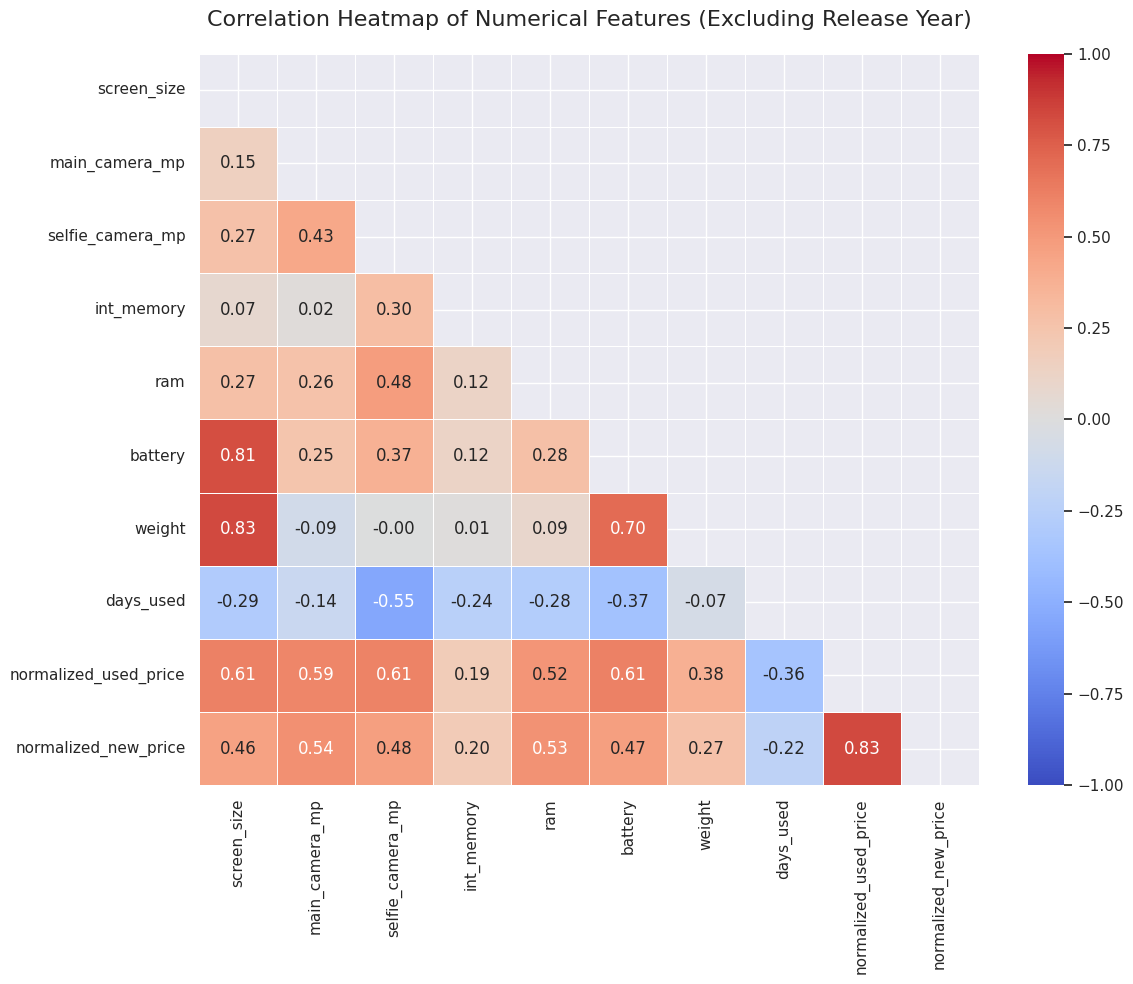

In [ ]:
# Selects only numerical columns for correlation analysis
numerical_df = df.select_dtypes(include=[np.number])

# Remove release_year from the correlation analysis
if 'release_year' in numerical_df.columns:
    numerical_df = numerical_df.drop('release_year', axis=1)

# Calculates the correlation matrix
correlation_matrix = numerical_df.corr()

# Creates a mask for the upper triangle to avoid redundancy
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Create a heatmap with the correlation values
heatmap = sns.heatmap(correlation_matrix,
                      mask=mask,
                      annot=True,           # Show correlation values
                      fmt=".2f",            # Format to 2 decimal places
                      cmap="coolwarm",      # Red-blue color map
                      vmin=-1, vmax=1,      # Set limits for correlation values
                      linewidths=0.5)

plt.title("Correlation Heatmap of Numerical Features (Excluding Release Year)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

##### Observations:

* The normalized price of a used device is highly positively correlated with the normalized new price.

* It is also positlivly correlated with the screen size, selfie camera, battery and normalized new price.

* It is negatively correlated with the number of days the device has been used.

## Model Building - Linear Regression

In [ ]:
# Prepare the data for OLS regression
# Make a copy to avoid modifying original data
x_train_prep = x_train.copy()

# Handle different data types
# Convert boolean columns to integers
bool_cols = x_train_prep.select_dtypes(include=['bool']).columns
for col in bool_cols:
    x_train_prep[col] = x_train_prep[col].astype(int)

# Handle date columns if any exist
date_cols = x_train_prep.select_dtypes(include=['datetime64']).columns
for col in date_cols:
    x_train_prep[f"{col}_year"] = x_train_prep[col].dt.year
    x_train_prep[f"{col}_month"] = x_train_prep[col].dt.month
    x_train_prep = x_train_prep.drop(col, axis=1)

# Convert categorical variables to numeric using one-hot encoding
categorical_cols = x_train_prep.select_dtypes(include=['object', 'category']).columns
if len(categorical_cols) > 0:
    x_train_prep = pd.get_dummies(x_train_prep, columns=categorical_cols, drop_first=True)

# Ensure specific binary columns are numeric (like '4g', '5g')
binary_cols = ['4g', '5g']  # Adjust based on your actual column names
for col in binary_cols:
    if col in x_train_prep.columns:
        x_train_prep[col] = x_train_prep[col].astype(int)

# Convert any remaining columns to numeric
for col in x_train_prep.columns:
    x_train_prep[col] = pd.to_numeric(x_train_prep[col], errors='coerce')

# Handle any NaN values that might have been introduced during conversion
x_train_prep = x_train_prep.fillna(x_train_prep.mean())

# Check if there are still any non-numeric columns
non_numeric_cols = x_train_prep.select_dtypes(include=['object']).columns
if len(non_numeric_cols) > 0:
    print(f"Warning: Still have object columns after conversion: {list(non_numeric_cols)}")
    # Drop them if necessary
    x_train_prep = x_train_prep.drop(columns=non_numeric_cols)

# Add a constant term (intercept) to the model
x_train_with_const = sm.add_constant(x_train_prep)

# Ensure y_train is a Series, not a DataFrame
if isinstance(y_train, pd.DataFrame):
    y_train = y_train.iloc[:, 0]  # Convert to Series if it's a DataFrame

# Fit the OLS model
olsmodel1 = sm.OLS(y_train, x_train_with_const).fit()

#  Display the results
print(olsmodel1.summary())

# Save the model coefficients to a DataFrame
coefficients = pd.DataFrame({
    'Feature': x_train_with_const.columns,
    'Coefficient': olsmodel1.params,
    'P-value': olsmodel1.pvalues
})
print("\nModel Coefficients (sorted by absolute value):")
print(coefficients.sort_values(by='Coefficient', key=abs, ascending=False))

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.845
Model:                               OLS   Adj. R-squared:                  0.842
Method:                    Least Squares   F-statistic:                     268.7
Date:                   Mon, 27 Oct 2025   Prob (F-statistic):               0.00
Time:                           00:59:47   Log-Likelihood:                 123.85
No. Observations:                   2417   AIC:                            -149.7
Df Residuals:                       2368   BIC:                             134.0
Df Model:                             48                                         
Covariance Type:               nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------


### Interpretion:¶

* The Adjusted R-squared reflects the fit of the model.
The values generally range from 0 to 1, where a higher value indicates a better fit, assuming certain conditions are met.
The Adjusted R-squared is 0.845, which is close to 1 and indicates a good fit.

* The const coefficient is the Y-intercept.
The const coefficient is 1.3156

* The coefficient of a predictor variable represents the change in the output Y due to a change in the predictor variable (considering the other variables are held constant).
The coefficient of normalized_new_price is 0.431.

## Model Performance Check

In [ ]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0])

    return df_perf

In [ ]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmodel1_train_perf = model_performance_regression(olsmodel1, x_train, y_train)
olsmodel1_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.230,0.180,0.845,0.842,4.327


In [ ]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsmodel1_test_perf = model_performance_regression(olsmodel1, x_test, y_test) ## Complete the code to check the performance on test data
olsmodel1_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.238,0.185,0.842,0.835,4.502


## Checking Linear Regression Assumptions

- In order to make statistical inferences from a linear regression model, it is important to ensure that the assumptions of linear regression are satisfied.

### Test for Multicollinearity

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [ ]:
def checking_vif(predictors):
    """
    Function to calculate VIF
    predictors: independent variables
    """
    # Convert boolean columns to integers
    bool_cols = predictors.select_dtypes(include=['bool']).columns
    for col in bool_cols:
        predictors[col] = predictors[col].astype(int)

    # adding constant
    values = np.ones((predictors.shape[0], 1))
    predictors_1 = np.concatenate((values, predictors), axis=1)
    # list of vif values
    vif = [variance_inflation_factor(predictors_1, i) for i in range(predictors_1.shape[1])]

    # creating a dataframe for vif values
    vif_dataframe = pd.DataFrame()
    vif_dataframe["features"] = ['const'] + list(predictors.columns)
    vif_dataframe["vif_values"] = vif

    return vif_dataframe

In [ ]:
checking_vif(x_train)

,features,vif_values
0,const,0.000
1,const,0.000
2,screen_size,7.677
3,main_camera_mp,2.285
4,selfie_camera_mp,2.812
5,int_memory,1.364
6,ram,2.282
7,battery,4.082
8,weight,6.397
9,days_used,2.660


#### Treating Multicollinearity

In [ ]:
def treating_multicollinearity(predictors, target, high_vif_columns):
    """
    Checking the effect of dropping the columns showing high multicollinearity
    on model performance (adj. R-squared and RMSE)

    predictors: independent variables
    target: dependent variable
    high_vif_columns: columns having high VIF
    """
    # empty lists to store adj. R-squared and RMSE values
    adj_r2 = []
    rmse = []

    # build ols models by dropping one of the high VIF columns at a time
    # store the adjusted R-squared and RMSE in the lists defined previously
    for cols in high_vif_columns:
        # defining the new train set
        train = predictors.loc[:, ~predictors.columns.str.startswith(cols)]

        # create the model
        olsmodel = sm.OLS(target, train).fit()

        # adding adj. R-squared and RMSE to the lists
        adj_r2.append(olsmodel.rsquared_adj)
        rmse.append(np.sqrt(olsmodel.mse_resid))

    # creating a dataframe for the results
    temp = pd.DataFrame(
        {
            "col": high_vif_columns,
            "Adj. R-squared after_dropping col": adj_r2,
            "RMSE after dropping col": rmse,
        }
    ).sort_values(by="Adj. R-squared after_dropping col", ascending=False)
    temp.reset_index(drop=True, inplace=True)

    return temp

In [ ]:
list_high_vif = ['screen_size',
                 'weight',
                 'years_since_release',
                 'brand_name_apple',
                 'brand_name_Huawei',
                 'brand_name_Other',
                 'brand_name_Samsung',
                 'os_iOS']
res = treating_multicollinearity(x_train, y_train, list_high_vif)
res

,col,Adj. R-squared after_dropping col,RMSE after dropping col
0,brand_name_Huawei,0.842,0.232
1,brand_name_Other,0.842,0.232
2,os_iOS,0.842,0.232
3,brand_name_Samsung,0.842,0.232
4,brand_name_apple,0.842,0.232
5,years_since_release,0.840,0.234
6,screen_size,0.838,0.235
7,weight,0.838,0.235


In [ ]:
# specify the column to drop
col_to_drop = 'os_iOS'
# specify the train data from which to drop the column specified
x_train2 = x_train.loc[:, ~x_train.columns.str.startswith(col_to_drop)]
# specify the test data from which to drop the column specified
x_test2 = x_test.loc[:, ~x_test.columns.str.startswith(col_to_drop)]

# Check VIF again
vif = checking_vif(x_train2)
print("VIF after dropping ", col_to_drop)
vif

VIF after dropping  os_iOS


,features,vif_values
0,const,0.000
1,const,0.000
2,screen_size,7.608
3,main_camera_mp,2.282
4,selfie_camera_mp,2.802
5,int_memory,1.364
6,ram,2.267
7,battery,4.078
8,weight,6.378
9,days_used,2.660


In [ ]:
# specify the columns with high VIF
list_high_vif = ['screen_size',
                 'weight',
                 'years_since_release',
                 'brand_name_Huawei',
                 'brand_name_Other',
                 'brand_name_Samsung']

## check the effect on model performance after dropping specified columns from train data
res = treating_multicollinearity(x_train2, y_train, list_high_vif)
res

,col,Adj. R-squared after_dropping col,RMSE after dropping col
0,brand_name_Huawei,0.842,0.232
1,brand_name_Other,0.842,0.232
2,brand_name_Samsung,0.842,0.232
3,years_since_release,0.840,0.233
4,screen_size,0.838,0.235
5,weight,0.838,0.235


In [ ]:
col_to_drop = 'brand_name_Others'
x_train3 = x_train2.loc[:, ~x_train2.columns.str.startswith(col_to_drop)]
x_test3 = x_test2.loc[:, ~x_test2.columns.str.startswith(col_to_drop)]

vif = checking_vif(x_train3)
print("VIF after dropping ", col_to_drop)
vif

VIF after dropping  brand_name_Others


,features,vif_values
0,const,0.000
1,const,0.000
2,screen_size,7.563
3,main_camera_mp,2.280
4,selfie_camera_mp,2.802
5,int_memory,1.364
6,ram,2.266
7,battery,4.078
8,weight,6.358
9,days_used,2.660


In [ ]:
# specify the columns with high VIF
list_high_vif = ['screen_size',
            'weight',
            'years_since_release']

# check the effect on model performance after dropping specified columns from train data
res = treating_multicollinearity(x_train3, y_train, list_high_vif)
res

,col,Adj. R-squared after_dropping col,RMSE after dropping col
0,years_since_release,0.840,0.233
1,screen_size,0.838,0.235
2,weight,0.838,0.235


In [ ]:
col_to_drop = 'years_since_release'
x_train4 = x_train3.loc[:, ~x_train3.columns.str.startswith(col_to_drop)]
x_test4 = x_test3.loc[:, ~x_test3.columns.str.startswith(col_to_drop)]

vif = checking_vif(x_train4)
print("VIF after dropping ", col_to_drop)
vif

VIF after dropping  years_since_release


,features,vif_values
0,const,0.000
1,const,0.000
2,screen_size,7.298
3,main_camera_mp,2.269
4,selfie_camera_mp,2.501
5,int_memory,1.347
6,ram,2.264
7,battery,3.956
8,weight,6.134
9,days_used,1.909


In [ ]:
list_high_vif = ['screen_size',
            'weight']

# check the effect on model performance after dropping specified columns from train data
res = treating_multicollinearity(x_train4, y_train, list_high_vif)
res

,col,Adj. R-squared after_dropping col,RMSE after dropping col
0,weight,0.837,0.236
1,screen_size,0.835,0.237


In [ ]:
col_to_drop = 'weight'
x_train5 = x_train4.loc[:, ~x_train4.columns.str.startswith(col_to_drop)]
x_test5 = x_test4.loc[:, ~x_test4.columns.str.startswith(col_to_drop)]

# Check VIF again
vif = checking_vif(x_train5)
print("VIF after dropping ", col_to_drop)
vif

VIF after dropping  weight


,features,vif_values
0,const,0.000
1,const,0.000
2,screen_size,3.539
3,main_camera_mp,2.154
4,selfie_camera_mp,2.433
5,int_memory,1.346
6,ram,2.262
7,battery,3.624
8,days_used,1.832
9,normalized_new_price,2.891


#### Dropping variables with high p-value

In [ ]:
# check for p-values on the right dataset
predictors = x_train5.copy()
cols = predictors.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    x_train_aux = predictors[cols]

    # fitting the model
    model = sm.OLS(y_train, x_train_aux).fit()

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(selected_features)

['const', 'screen_size', 'main_camera_mp', 'selfie_camera_mp', 'ram', 'normalized_new_price', 'brand_name_Nokia', 'brand_name_Samsung', 'brand_name_Sony', 'brand_name_Xiaomi', '4g_yes']


In [ ]:
# specify the train data from which to select the specified columns
x_train6 = x_train5[selected_features]
# specify the test data from which to select the specified columns
x_test6 = x_test5[selected_features]

In [ ]:
# fit OLS() on updated dataset (no multicollinearity and no insignificant predictors)
olsmodel2 = sm.OLS(y_train, x_train6).fit()
print(olsmodel2.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.838
Model:                               OLS   Adj. R-squared:                  0.838
Method:                    Least Squares   F-statistic:                     1248.
Date:                   Sun, 26 Oct 2025   Prob (F-statistic):               0.00
Time:                           19:27:39   Log-Likelihood:                 73.961
No. Observations:                   2417   AIC:                            -125.9
Df Residuals:                       2406   BIC:                            -62.23
Df Model:                             10                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

In [ ]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmodel2_train_perf = model_performance_regression(olsmodel2, x_train6, y_train)
olsmodel2_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.235,0.184,0.838,0.838,4.415


In [ ]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsmodel2_test_perf = model_performance_regression(olsmodel2, x_test6, y_test)
olsmodel2_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.240,0.186,0.840,0.838,4.519


##### Observations

* Testing for multicollinearity, some columns were seen to have high vif and p-value.

* The following solumns were dropped: os_ios, brand_name_Others, years_since_release and weight.

* Following this, the vif values reduced.

* The features in x_train6 were used as the final set of predictor variables while the olsmod2 is the final model.

* With an Adjusted R-squared of 0.838, approximately 83.8% of the variance of normalized_used_price can be explained by the independent variables in the final model.

### Test for Linearity and Independence

In [ ]:
# a dataframe with actual, fitted and residual values
df_pred = pd.DataFrame()

df_pred["Actual Values"] = y_train  # actual values
df_pred["Fitted Values"] = olsmodel2.fittedvalues  # predicted values
df_pred["Residuals"] = olsmodel2.resid  # residuals

df_pred.head()

,Actual Values,Fitted Values,Residuals
3026,4.087,3.858,0.229
1525,4.448,4.589,-0.140
1128,4.315,4.277,0.038
3003,4.282,4.275,0.007
2907,4.456,4.464,-0.007


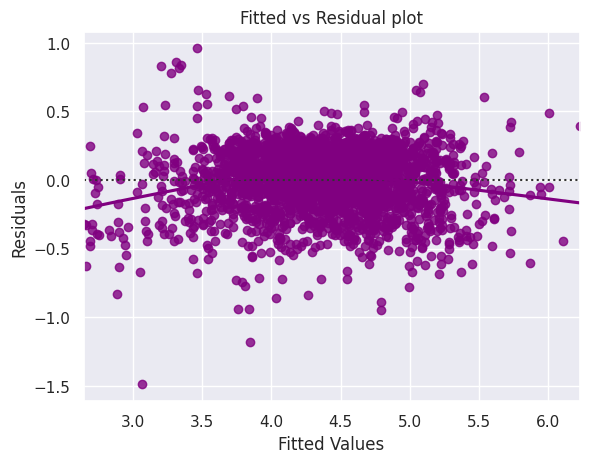

In [ ]:
# plot of the fitted values vs residuals

sns.residplot(
    data=df_pred, x="Fitted Values", y="Residuals", color="purple", lowess=True)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted vs Residual plot")
plt.show()

#### Observation:

* There is no discernable pattern in the plot of fitted values vs residuals hence the assumption of linearity and independence has been met.

### Test for Normality

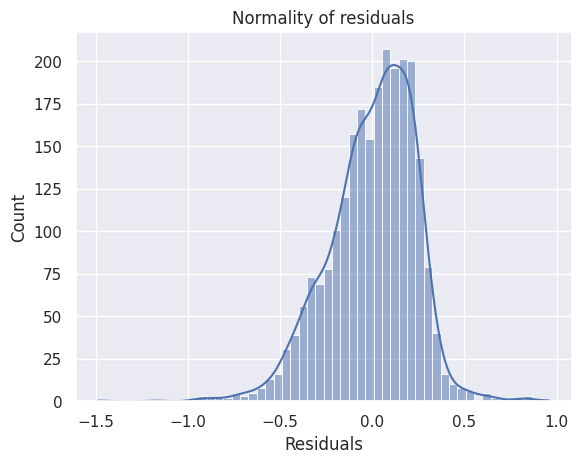

In [ ]:
sns.histplot(data=df_pred, x="Residuals", kde=True) # create a histogram of the distribution of residuals
plt.title("Normality of residuals")
plt.show()

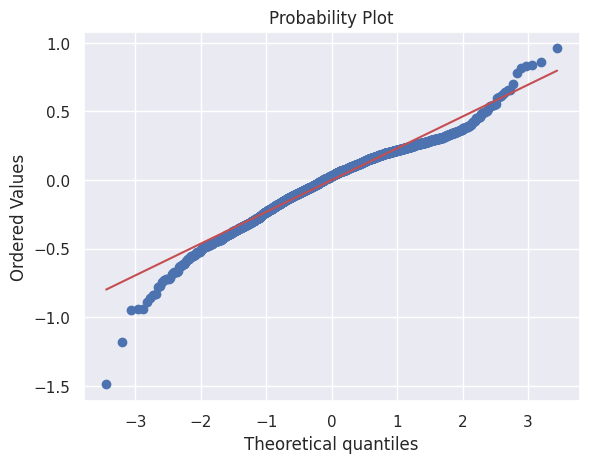

In [ ]:
import pylab
import scipy.stats as stats

stats.probplot(df_pred["Residuals"], dist="norm", plot=pylab) ## Complete the code check Q-Q plot
plt.show()

In [ ]:
stats.shapiro(df_pred["Residuals"]) ## Complete the code to apply the Shapiro-Wilks test

ShapiroResult(statistic=np.float64(0.9723449123150835), pvalue=np.float64(3.293539646913425e-21))

#### Observations:

* The histogram of residuals appears to be close to normally distributed.

* This is also seen in the probability plot.

* However, the p-value of 3.293539646913425e-21 found in the Shapiro-Wilk test is < 0.05. This suggests that residuals are not normally distributed.

### Test for Homoscedasticity

In [ ]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(df_pred["Residuals"], x_train6) ## Complete the code with the right train data to apply the Goldfeldquandt test
lzip(name, test)

[('F statistic', np.float64(1.054855117195117)),
 ('p-value', np.float64(0.1778019636330485))]

In [ ]:
# predictions on the test set
pred = olsmodel2.predict(x_test6)

df_pred_test = pd.DataFrame({"Actual": y_test, "Predicted": pred})
df_pred_test.sample(10, random_state=1)

,Actual,Predicted
1995,4.567,4.379
2341,3.696,3.943
1913,3.592,3.787
688,4.306,4.151
650,4.522,5.105
2291,4.259,4.416
40,4.998,5.414
1884,3.875,4.083
2538,4.207,4.009
45,5.380,5.289


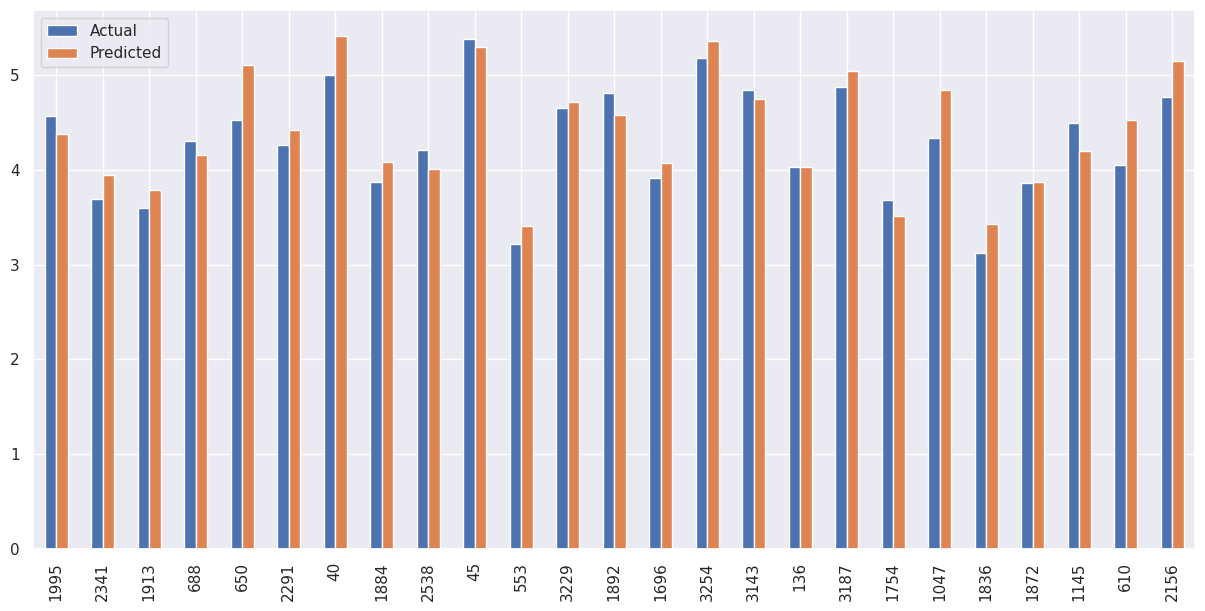

In [ ]:
df3 = df_pred_test.sample(25, random_state=1)
df3.plot(kind="bar", figsize=(15, 7))
plt.show()

#### Observations:

* The p-value of 0.1778019636330485 is > 0.05 hence the residuals are homoscedastic.

## Final Model

In [ ]:
x_train_final = x_train6.copy()
x_test_final = x_test6.copy()

In [ ]:
olsmodel_final = sm.OLS(y_train, x_train_final).fit() # the final model
print(olsmodel_final.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.838
Model:                               OLS   Adj. R-squared:                  0.838
Method:                    Least Squares   F-statistic:                     1248.
Date:                   Sun, 26 Oct 2025   Prob (F-statistic):               0.00
Time:                           19:39:08   Log-Likelihood:                 73.961
No. Observations:                   2417   AIC:                            -125.9
Df Residuals:                       2406   BIC:                            -62.23
Df Model:                             10                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

In [ ]:
# checking the model performance on train set (seen 70% data)
print("Training Performance\n")
olsmodel_final_train_perf = model_performance_regression(olsmodel_final, x_train_final, y_train)
olsmodel_final_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.235,0.184,0.838,0.838,4.415


In [ ]:
# checking the model performance on test set (seen 30% data)
print("Test Performance\n")
olsmodel_final_test_perf = model_performance_regression(olsmodel_final, x_test_final, y_test)
olsmodel_final_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.240,0.186,0.840,0.838,4.519


#### Observations:

* The Adjusted R-squared of 0.838 indicates that the model explains 83.8% of the variance in the data.

* The values in both the train and test models are similar.

* The final olsmodel makes a good prediction of the dependent variable.

## Actionable Insights and Recommendations

- The brand, screen size, the main and selfie cameras, weight, storage (RAM and internal memory), network type (4G), and the price of a similar device which is new significantly impacts the price of a used device.

- There is a huge market for used devices however, the competition is strong.

- It is importance for Recell to maintain a good standard in order to remain relevant on the market.

- Used phones should be refurbished properly and in good condition before sale. Recell should ensure that the used devices they sell met the market standards and demands.

- It is important to note that current technological advancements have it possible for the manufacture of light weight, large screen devices with high quality main and selfie cameras and various storage option devices. Recell can consider focusing on such used phones.


___